In [1]:
!pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]


In [2]:
import pandas as pd
import numpy as np
import sqlite3
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("wyattowalsh/basketball")
db_path = os.path.join(path, 'nba.sqlite')

# Load tables
with sqlite3.connect(db_path) as conn:
    game = pd.read_sql('SELECT * FROM "game"', conn)
    game_summary = pd.read_sql('SELECT * FROM "game_summary"', conn)
    other_stats = pd.read_sql('SELECT * FROM "other_stats"', conn)
    officials = pd.read_sql('SELECT * FROM "officials"', conn)
    inactive_players = pd.read_sql('SELECT * FROM "inactive_players"', conn)
    game_info = pd.read_sql('SELECT * FROM "game_info"', conn)
    line_score = pd.read_sql('SELECT * FROM "line_score"', conn)
    player = pd.read_sql('SELECT * FROM "player"', conn)
    team = pd.read_sql('SELECT * FROM "team"', conn)
    common_player_info = pd.read_sql('SELECT * FROM "common_player_info"', conn)
    team_details = pd.read_sql('SELECT * FROM "team_details"', conn)
    team_history = pd.read_sql('SELECT * FROM "team_history"', conn)
    draft_combine_stats = pd.read_sql('SELECT * FROM "draft_combine_stats"', conn)
    draft_history = pd.read_sql('SELECT * FROM "draft_history"', conn)
    team_info_common = pd.read_sql('SELECT * FROM "team_info_common"', conn)
    players_per_game = pd.read_sql('''
        SELECT DISTINCT
            game_id,
            player1_id as player_id,
            player1_name as player_name,
            player1_team_id as team_id
        FROM play_by_play
        WHERE player1_id IS NOT NULL
            AND player1_id != 0
            AND player1_name IS NOT NULL
            AND player1_name != ""
    ''', conn)

# Prep game table
game['game_id'] = game['game_id'].astype(str)
game['game_date'] = pd.to_datetime(game['game_date'])

# Build game outcomes
game_outcomes = game[['game_id', 'game_date', 'team_id_home', 'team_id_away', 'wl_home', 'pts_home', 'pts_away']].copy()
game_outcomes['team_id_home'] = game_outcomes['team_id_home'].astype(str)
game_outcomes['team_id_away'] = game_outcomes['team_id_away'].astype(str)

# Prep players_per_game
players_per_game['game_id'] = players_per_game['game_id'].astype(str)
players_per_game['team_id'] = players_per_game['team_id'].astype(float)
players_per_game = players_per_game.dropna(subset=['team_id'])
players_per_game['team_id'] = players_per_game['team_id'].astype(int).astype(str)
# Merge
pgm = players_per_game.merge(game_outcomes, on='game_id').copy()

# Create won column
pgm['won'] = (
    ((pgm['team_id'] == pgm['team_id_home']) & (pgm['wl_home'] == 'W')) |
    ((pgm['team_id'] == pgm['team_id_away']) & (pgm['wl_home'] == 'L'))
).astype(int)

pgm = pgm.sort_values('game_date').reset_index(drop=True)

print("Done!")
print(pgm['won'].value_counts())
pgm[['game_id', 'player_name', 'team_id', 'game_date', 'won']].head(10)

# Debug won column
row = pgm.iloc[0]
print("team_id:", row['team_id'], type(row['team_id']))
print("team_id_home:", row['team_id_home'], type(row['team_id_home']))
print("team_id_away:", row['team_id_away'], type(row['team_id_away']))
print("wl_home:", row['wl_home'])
print("match_home:", row['team_id'] == row['team_id_home'])
print("match_away:", row['team_id'] == row['team_id_away'])

100%|██████████| 697M/697M [00:35<00:00, 20.7MB/s] 

Extracting files...


Done!
won
0    305696
1    304675
Name: count, dtype: int64
team_id: 1610612747 <class 'str'>
team_id_home: 1610612747 <class 'str'>
team_id_away: 1610612756 <class 'str'>
wl_home: W
match_home: True
match_away: False


In [3]:
# Player Elo system
K = 32  # how fast ratings change
LEGACY_FLOOR = 1400  # veterans don't drop below this
DEFAULT_ELO = 1200  # starting rating for new players

player_elo = {}  # player_id -> current elo
player_games = {}  # player_id -> number of games played

elo_records = []  # store elo before each game (for features later)

for _, row in pgm.iterrows():
    pid = row['player_id']

    # Get current elo (or default)
    elo = player_elo.get(pid, DEFAULT_ELO)
    games_played = player_games.get(pid, 0)

    # Record elo BEFORE this game (this is what we'll use as a feature)
    elo_records.append({
        'game_id': row['game_id'],
        'player_id': pid,
        'player_name': row['player_name'],
        'team_id': row['team_id'],
        'game_date': row['game_date'],
        'elo_before': elo,
        'games_played': games_played,
        'won': row['won']
    })

    # Update elo after game
    expected = 1 / (1 + 10 ** ((DEFAULT_ELO - elo) / 400))
    new_elo = elo + K * (row['won'] - expected)

    # Apply legacy floor
    if games_played > 200:
        new_elo = max(new_elo, LEGACY_FLOOR)

    player_elo[pid] = new_elo
    player_games[pid] = games_played + 1

elo_df = pd.DataFrame(elo_records)
print("Done!")
print(elo_df.shape)
elo_df.head(10)

Done!
(610371, 8)


,game_id,player_id,player_name,team_id,game_date,elo_before,games_played,won
0,0029600012,406,Shaquille O'Neal,1610612747,1996-11-01,1200.0,0,1
1,0029600010,36,Sarunas Marciulionis,1610612743,1996-11-01,1200.0,0,0
2,0029600010,894,Ricky Pierce,1610612743,1996-11-01,1200.0,0,0
3,0029600010,469,Jamal Mashburn,1610612742,1996-11-01,1200.0,0,1
4,0029600010,785,Eric Murdock,1610612743,1996-11-01,1200.0,0,0
5,0029600010,434,Tony Dumas,1610612742,1996-11-01,1200.0,0,1
6,0029600010,122,Fred Roberts,1610612742,1996-11-01,1200.0,0,1
7,0029600010,78,LaSalle Thompson,1610612743,1996-11-01,1200.0,0,0
8,0029600003,934,Derrick Coleman,1610612755,1996-11-01,1200.0,0,0
9,0029600003,221,Clar. Weatherspoon,1610612755,1996-11-01,1200.0,0,0


In [4]:
# Top 20 players by final elo
final_elos = pd.DataFrame([
    {'player_id': pid, 'elo': elo, 'games_played': player_games[pid]}
    for pid, elo in player_elo.items()
])

# Merge with player names
name_map = elo_df[['player_id', 'player_name']].drop_duplicates('player_id')
final_elos = final_elos.merge(name_map, on='player_id')
final_elos = final_elos[final_elos['games_played'] >= 100].sort_values('elo', ascending=False)
print(final_elos.head(20).to_string())

     player_id          elo  games_played         player_name
815       2446  1492.871628           762       Rasual Butler
927       2440  1489.974144           854         Matt Barnes
670       2036  1482.545739           382          Chris Mihm
236        165  1478.074594           324     Hakeem Olajuwon
101        345  1472.558995           390        Terry Porter
273         15  1467.087956           571     Eric Piatkowski
926       2137  1466.892909           281           Ime Udoka
317        689  1466.892909           673        Theo Ratliff
55         376  1461.068801           293       Eric Montross
479       1533  1461.068801           744     Anthony Johnson
200        166  1461.068801           332          Ron Harper
210        693  1456.682099           865           Joe Smith
797       2243  1455.651514           455    Brian Scalabrine
286        147  1451.564038           708          Jalen Rose
2361   1628964  1449.591682           267            Mo Bamba
9       

In [5]:
!pip install nba_api

In [6]:
from nba_api.stats.endpoints import playergamelog
from nba_api.stats.static import players
import time

# Get all players
all_players = players.get_players()
print(f"Total players: {len(all_players)}")
print(all_players[0])

Total players: 5103
{'id': 76001, 'full_name': 'Alaa Abdelnaby', 'first_name': 'Alaa', 'last_name': 'Abdelnaby', 'is_active': False}


In [7]:
from nba_api.stats.endpoints import leaguegamelog
import time

# Test with one season first
gamelog = leaguegamelog.LeagueGameLog(season='2022-23', player_or_team_abbreviation='P')
df = gamelog.get_data_frames()[0]
print(df.shape)
print(df.columns.tolist())
df.head()

(25895, 32)
['SEASON_ID', 'PLAYER_ID', 'PLAYER_NAME', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS', 'FANTASY_PTS', 'VIDEO_AVAILABLE']


,SEASON_ID,PLAYER_ID,PLAYER_NAME,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,...,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,FANTASY_PTS,VIDEO_AVAILABLE
0,22022,201143,Al Horford,1610612738,BOS,Boston Celtics,0022200001,2022-10-18,BOS vs. PHI,W,...,5,1,0,0,0,4,6,8,13.5,1
1,22022,203943,Noah Vonleh,1610612738,BOS,Boston Celtics,0022200001,2022-10-18,BOS vs. PHI,W,...,2,0,1,1,0,4,2,7,10.4,1
2,22022,1631157,Ryan Rollins,1610612744,GSW,Golden State Warriors,0022200002,2022-10-18,GSW vs. LAL,W,...,1,1,0,0,0,2,0,-3,2.7,1
3,22022,1630346,Matt Ryan,1610612747,LAL,Los Angeles Lakers,0022200002,2022-10-18,LAL @ GSW,L,...,1,0,1,0,1,2,3,1,6.2,1
4,22022,200782,P.J. Tucker,1610612755,PHI,Philadelphia 76ers,0022200001,2022-10-18,PHI @ BOS,L,...,4,0,0,1,2,2,6,-6,11.8,1


In [8]:
seasons = [f"{y}-{str(y+1)[-2:]}" for y in range(1996, 2024)]
print(seasons)

['1996-97', '1997-98', '1998-99', '1999-00', '2000-01', '2001-02', '2002-03', '2003-04', '2004-05', '2005-06', '2006-07', '2007-08', '2008-09', '2009-10', '2010-11', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24']


In [9]:
all_gamelogs = []

for season in seasons:
    try:
        gamelog = leaguegamelog.LeagueGameLog(season=season, player_or_team_abbreviation='P')
        df = gamelog.get_data_frames()[0]
        all_gamelogs.append(df)
        print(f"{season}: {len(df)} rows")
        time.sleep(1)  # avoid rate limiting
    except Exception as e:
        print(f"{season} failed: {e}")

player_gamelogs = pd.concat(all_gamelogs, ignore_index=True)
print(f"\nTotal: {player_gamelogs.shape}")

1996-97: 23757 rows
1997-98: 24001 rows
1998-99: 14923 rows
1999-00: 24298 rows
2000-01: 23973 rows
2001-02: 23909 rows
2002-03: 23941 rows
2003-04: 23894 rows
2004-05: 24956 rows
2005-06: 24917 rows
2006-07: 25086 rows
2007-08: 24886 rows
2008-09: 24629 rows
2009-10: 24813 rows
2010-11: 25153 rows
2011-12: 20758 rows
2012-13: 25757 rows
2013-14: 25618 rows
2014-15: 25981 rows
2015-16: 26078 rows
2016-17: 26139 rows
2017-18: 26107 rows
2018-19: 26101 rows
2019-20: 22393 rows
2020-21: 23054 rows
2021-22: 26039 rows
2022-23: 25895 rows
2023-24: 26401 rows

Total: (683457, 32)


In [10]:
# Normalize key stats to create a performance score per game
player_gamelogs['GAME_DATE'] = pd.to_datetime(player_gamelogs['GAME_DATE'])
player_gamelogs['GAME_ID'] = player_gamelogs['GAME_ID'].astype(str)
player_gamelogs['TEAM_ID'] = player_gamelogs['TEAM_ID'].astype(str)

# Fill nulls
player_gamelogs['PLUS_MINUS'] = player_gamelogs['PLUS_MINUS'].fillna(0)
player_gamelogs['MIN'] = pd.to_numeric(player_gamelogs['MIN'], errors='coerce').fillna(0)
player_gamelogs['PTS'] = player_gamelogs['PTS'].fillna(0)
player_gamelogs['REB'] = player_gamelogs['REB'].fillna(0)
player_gamelogs['AST'] = player_gamelogs['AST'].fillna(0)
player_gamelogs['STL'] = player_gamelogs['STL'].fillna(0)
player_gamelogs['BLK'] = player_gamelogs['BLK'].fillna(0)
player_gamelogs['TOV'] = player_gamelogs['TOV'].fillna(0)

# Performance score = weighted combo of stats (like fantasy points but custom)
player_gamelogs['perf_score'] = (
    player_gamelogs['PTS'] * 1.0 +
    player_gamelogs['REB'] * 1.2 +
    player_gamelogs['AST'] * 1.5 +
    player_gamelogs['STL'] * 2.0 +
    player_gamelogs['BLK'] * 2.0 +
    player_gamelogs['TOV'] * -1.0 +
    player_gamelogs['PLUS_MINUS'] * 0.5
)

# Sort chronologically
player_gamelogs = player_gamelogs.sort_values('GAME_DATE').reset_index(drop=True)

print("Done!")
print(player_gamelogs[['PLAYER_NAME', 'GAME_DATE', 'PTS', 'PLUS_MINUS', 'perf_score']].head(10))

Done!
       PLAYER_NAME  GAME_DATE  PTS  PLUS_MINUS  perf_score
0     Antonio Lang 1996-11-01    0          -7         1.5
1    Kerry Kittles 1996-11-01    5           2        10.7
2       David Wood 1996-11-01    0          -5        -2.5
3  Alonzo Mourning 1996-11-01   26          14        49.4
4     Keith Askins 1996-11-01    5          -1         6.9
5     Corie Blount 1996-11-01    7           1        13.7
6      Malik Sealy 1996-11-01   15           9        32.6
7     Horace Grant 1996-11-01   14          -2        42.4
8    Lamond Murray 1996-11-01   13          13        30.4
9         Sam Mack 1996-11-01    0          -1         0.2


In [11]:
K = 20
LEGACY_FLOOR = 1400
LEGACY_GAMES = 400
DEFAULT_ELO = 1200

player_elo = {}
player_games = {}
player_peak_elo = {}

elo_records = []

for _, row in player_gamelogs.iterrows():
    pid = row['PLAYER_ID']
    elo = player_elo.get(pid, DEFAULT_ELO)
    games_played = player_games.get(pid, 0)
    peak = player_peak_elo.get(pid, DEFAULT_ELO)

    # Record elo BEFORE this game
    elo_records.append({
        'game_id': row['GAME_ID'],
        'player_id': pid,
        'player_name': row['PLAYER_NAME'],
        'team_id': row['TEAM_ID'],
        'game_date': row['GAME_DATE'],
        'elo_before': elo,
        'peak_elo': peak,
        'games_played': games_played,
        'min': row['MIN'],
        'perf_score': row['perf_score'],
        'won': 1 if row['WL'] == 'W' else 0
    })

    # Performance-weighted K — stars get bigger updates
    perf_weight = np.clip(row['perf_score'] / 30, 0.5, 2.5)
    k_adjusted = K * perf_weight

    # Expected score based on current elo vs league average
    expected = 1 / (1 + 10 ** ((DEFAULT_ELO - elo) / 400))
    actual = 1 if row['WL'] == 'W' else 0
    new_elo = elo + k_adjusted * (actual - expected)

    # Legacy floor — good veterans don't crater
    if games_played > LEGACY_GAMES:
        legacy_floor = LEGACY_FLOOR + (peak - LEGACY_FLOOR) * 0.3
        new_elo = max(new_elo, legacy_floor)

    player_elo[pid] = new_elo
    player_peak_elo[pid] = max(peak, new_elo)
    player_games[pid] = games_played + 1

elo_df = pd.DataFrame(elo_records)
print("Done!")
print(elo_df.shape)

Done!
(683457, 11)


In [12]:
final_elos = pd.DataFrame([
    {'player_id': pid, 'elo': elo, 'games_played': player_games[pid], 'peak_elo': player_peak_elo[pid]}
    for pid, elo in player_elo.items()
])

name_map = elo_df[['player_id', 'player_name']].drop_duplicates('player_id')
final_elos = final_elos.merge(name_map, on='player_id')
final_elos = final_elos[final_elos['games_played'] >= 200].sort_values('elo', ascending=False)
print(final_elos.head(20).to_string())

      player_id          elo  games_played     peak_elo       player_name
1832     203954  1498.814632           433  1498.814632       Joel Embiid
1327     201950  1483.723796           975  1515.006359      Jrue Holiday
1196     201143  1483.225342          1078  1523.082993        Al Horford
472        1495  1482.721626          1392  1540.580490        Tim Duncan
1518     203076  1480.858972           736  1516.408315     Anthony Davis
1445     202681  1480.621011           729  1493.780130      Kyrie Irving
890        2544  1474.476515          1492  1585.774222      LeBron James
1524     203110  1466.764460           813  1607.318722    Draymond Green
1313     201939  1465.142140           956  1617.140468     Stephen Curry
246         406  1464.782830           912  1566.107222  Shaquille O'Neal
1240     201601  1464.762717           689  1503.696984  Luc Mbah a Moute
1430     202691  1464.637005           793  1601.213243     Klay Thompson
1906    1628401  1464.634285          

In [13]:
# For each game, compute team elo aggregates
team_elo_per_game = elo_df.groupby(['game_id', 'team_id']).agg(
    avg_elo=('elo_before', 'mean'),
    max_elo=('elo_before', 'max'),
    top5_elo=('elo_before', lambda x: x.nlargest(5).mean()),
    num_players=('elo_before', 'count')
).reset_index()

print(team_elo_per_game.shape)
team_elo_per_game.head()

(66172, 6)


,game_id,team_id,avg_elo,max_elo,top5_elo,num_players
0,0020000001,1610612752,1304.315258,1468.819331,1362.180666,12
1,0020000001,1610612755,1293.023258,1366.646761,1338.101805,12
2,0020000002,1610612739,1200.449562,1305.350515,1253.114008,11
3,0020000002,1610612751,1177.500843,1213.187850,1200.723441,10
4,0020000003,1610612753,1235.790643,1314.373738,1284.124189,10


In [14]:
# Pivot so home and away team elos are on the same row
game['game_id'] = game['game_id'].astype(str)
game['team_id_home'] = game['team_id_home'].astype(str)
game['team_id_away'] = game['team_id_away'].astype(str)
game['game_date'] = pd.to_datetime(game['game_date'])

team_elo_per_game['game_id'] = team_elo_per_game['game_id'].astype(str)
team_elo_per_game['team_id'] = team_elo_per_game['team_id'].astype(str)

# Merge home team elos
features = game.merge(
    team_elo_per_game.add_suffix('_home').rename(columns={'game_id_home': 'game_id'}),
    left_on=['game_id', 'team_id_home'],
    right_on=['game_id', 'team_id_home']
)

# Merge away team elos
features = features.merge(
    team_elo_per_game.add_suffix('_away').rename(columns={'game_id_away': 'game_id'}),
    left_on=['game_id', 'team_id_away'],
    right_on=['game_id', 'team_id_away']
)

print(features.shape)
print(features[['game_id', 'game_date', 'team_name_home', 'team_name_away', 'avg_elo_home', 'avg_elo_away', 'top5_elo_home', 'top5_elo_away', 'wl_home']].head())

(30627, 63)
      game_id  game_date         team_name_home        team_name_away  \
0  0029600012 1996-11-01     Los Angeles Lakers          Phoenix Suns   
1  0029600005 1996-11-01             Miami Heat         Atlanta Hawks   
2  0029600002 1996-11-01        New Jersey Nets   Cleveland Cavaliers   
3  0029600007 1996-11-01        Detroit Pistons        Indiana Pacers   
4  0029600013 1996-11-01  Golden State Warriors  Los Angeles Clippers   

   avg_elo_home  avg_elo_away  top5_elo_home  top5_elo_away wl_home  
0        1200.0        1200.0         1200.0         1200.0       W  
1        1200.0        1200.0         1200.0         1200.0       W  
2        1200.0        1200.0         1200.0         1200.0       L  
3        1200.0        1200.0         1200.0         1200.0       W  
4        1200.0        1200.0         1200.0         1200.0       L  


In [15]:
# Filter to regular season only
features = features[features['season_type'] == 'Regular Season'].copy()

# Create target variable
features['home_win'] = (features['wl_home'] == 'W').astype(int)

# Sort by date
features = features.sort_values('game_date').reset_index(drop=True)

# Rolling team stats — last 10 games for each team
# We'll compute these from the game table directly
game_reg = game[game['season_type'] == 'Regular Season'].sort_values('game_date').copy()

# Build per-team per-game rolling stats
home_stats = game_reg[['game_id', 'game_date', 'team_id_home', 'pts_home', 'plus_minus_home', 'fg_pct_home', 'fg3_pct_home', 'ft_pct_home', 'reb_home', 'ast_home', 'tov_home']].copy()
home_stats.columns = ['game_id', 'game_date', 'team_id', 'pts', 'plus_minus', 'fg_pct', 'fg3_pct', 'ft_pct', 'reb', 'ast', 'tov']
home_stats['is_home'] = 1

away_stats = game_reg[['game_id', 'game_date', 'team_id_away', 'pts_away', 'plus_minus_away', 'fg_pct_away', 'fg3_pct_away', 'ft_pct_away', 'reb_away', 'ast_away', 'tov_away']].copy()
away_stats.columns = ['game_id', 'game_date', 'team_id', 'pts', 'plus_minus', 'fg_pct', 'fg3_pct', 'ft_pct', 'reb', 'ast', 'tov']
away_stats['is_home'] = 0

team_game_stats = pd.concat([home_stats, away_stats]).sort_values('game_date').reset_index(drop=True)

# Compute rolling 10-game averages per team (shift 1 so we don't leak current game)
roll_cols = ['pts', 'plus_minus', 'fg_pct', 'fg3_pct', 'ft_pct', 'reb', 'ast', 'tov']
team_game_stats = team_game_stats.sort_values(['team_id', 'game_date'])

for col in roll_cols:
    team_game_stats[f'roll10_{col}'] = (
        team_game_stats.groupby('team_id')[col]
        .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
    )

print("Done!")
print(team_game_stats[['team_id', 'game_date', 'pts', 'roll10_pts', 'roll10_plus_minus']].head(20))

Done!
         team_id  game_date    pts  roll10_pts  roll10_plus_minus
1793  1610610023 1949-11-03  110.0         NaN                NaN
1820  1610610023 1949-11-08   70.0         NaN                NaN
1833  1610610023 1949-11-09  102.0         NaN                NaN
1862  1610610023 1949-11-12   69.0   94.000000          11.333333
1866  1610610023 1949-11-13   81.0   87.750000           4.750000
1880  1610610023 1949-11-15   83.0   86.400000           6.200000
1912  1610610023 1949-11-19   83.0   85.833333           7.000000
1939  1610610023 1949-11-21   85.0   85.428571           6.428571
1958  1610610023 1949-11-24  123.0   85.375000           3.875000
1970  1610610023 1949-11-26   73.0   89.555556           3.222222
1985  1610610023 1949-11-27  111.0   87.900000           3.900000
1992  1610610023 1949-11-28  101.0   88.000000           3.600000
2017  1610610023 1949-12-01   81.0   91.100000           4.200000
2048  1610610023 1949-12-05   88.0   89.000000           4.800000
2064

In [16]:
# Merge rolling stats for home and away teams
roll_feature_cols = ['game_id', 'team_id'] + [f'roll10_{c}' for c in roll_cols]

features = features.merge(
    team_game_stats[roll_feature_cols].rename(columns={c: f'{c}_home' for c in roll_feature_cols if c not in ['game_id', 'team_id']}),
    left_on=['game_id', 'team_id_home'],
    right_on=['game_id', 'team_id'],
    how='left'
).drop(columns='team_id')

features = features.merge(
    team_game_stats[roll_feature_cols].rename(columns={c: f'{c}_away' for c in roll_feature_cols if c not in ['game_id', 'team_id']}),
    left_on=['game_id', 'team_id_away'],
    right_on=['game_id', 'team_id'],
    how='left'
).drop(columns='team_id')

print(features.shape)
print([c for c in features.columns if 'roll10' in c])

(30627, 80)
['roll10_pts_home', 'roll10_plus_minus_home', 'roll10_fg_pct_home', 'roll10_fg3_pct_home', 'roll10_ft_pct_home', 'roll10_reb_home', 'roll10_ast_home', 'roll10_tov_home', 'roll10_pts_away', 'roll10_plus_minus_away', 'roll10_fg_pct_away', 'roll10_fg3_pct_away', 'roll10_ft_pct_away', 'roll10_reb_away', 'roll10_ast_away', 'roll10_tov_away']


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Final feature columns
feature_cols = [
    'avg_elo_home', 'avg_elo_away',
    'top5_elo_home', 'top5_elo_away',
    'max_elo_home', 'max_elo_away',
    'roll10_pts_home', 'roll10_pts_away',
    'roll10_plus_minus_home', 'roll10_plus_minus_away',
    'roll10_fg_pct_home', 'roll10_fg_pct_away',
    'roll10_fg3_pct_home', 'roll10_fg3_pct_away',
    'roll10_reb_home', 'roll10_reb_away',
    'roll10_ast_home', 'roll10_ast_away',
    'roll10_tov_home', 'roll10_tov_away',
]

# Drop rows with nulls in features
model_df = features[feature_cols + ['home_win', 'game_date']].dropna().copy()

# Add elo differentials
model_df['elo_diff'] = model_df['avg_elo_home'] - model_df['avg_elo_away']
model_df['top5_elo_diff'] = model_df['top5_elo_home'] - model_df['top5_elo_away']
model_df['roll10_pts_diff'] = model_df['roll10_pts_home'] - model_df['roll10_pts_away']
model_df['roll10_plus_minus_diff'] = model_df['roll10_plus_minus_home'] - model_df['roll10_plus_minus_away']

feature_cols += ['elo_diff', 'top5_elo_diff', 'roll10_pts_diff', 'roll10_plus_minus_diff']

X = model_df[feature_cols]
y = model_df['home_win']

# Time-based split — train on older games, test on recent
split_date = '2021-01-01'
X_train = X[model_df['game_date'] < split_date]
y_train = y[model_df['game_date'] < split_date]
X_test = X[model_df['game_date'] >= split_date]
y_test = y[model_df['game_date'] >= split_date]

print(f"Train: {len(X_train)} games, Test: {len(X_test)} games")

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_scaled))
print(f"Logistic Regression accuracy: {lr_acc:.3f}")

# Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05)
gb.fit(X_train, y_train)
gb_acc = accuracy_score(y_test, gb.predict(X_test))
print(f"Gradient Boosting accuracy: {gb_acc:.3f}")

Train: 27151 games, Test: 3473 games
Logistic Regression accuracy: 0.638
Gradient Boosting accuracy: 0.632


In [18]:
# Feature importance from gradient boosting
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.to_string())

                   feature  importance
20                elo_diff    0.635683
23  roll10_plus_minus_diff    0.085792
21           top5_elo_diff    0.026838
8   roll10_plus_minus_home    0.023371
3            top5_elo_away    0.022561
1             avg_elo_away    0.020400
2            top5_elo_home    0.012854
13     roll10_fg3_pct_away    0.012788
5             max_elo_away    0.012721
7          roll10_pts_away    0.012271
10      roll10_fg_pct_home    0.012089
0             avg_elo_home    0.011946
12     roll10_fg3_pct_home    0.011573
15         roll10_reb_away    0.011000
4             max_elo_home    0.010934
17         roll10_ast_away    0.010784
9   roll10_plus_minus_away    0.010568
19         roll10_tov_away    0.009719
18         roll10_tov_home    0.009592
16         roll10_ast_home    0.009157
6          roll10_pts_home    0.009132
11      roll10_fg_pct_away    0.006947
22         roll10_pts_diff    0.006401
14         roll10_reb_home    0.004880


In [19]:
# Baseline: always predict home team wins
baseline = accuracy_score(y_test, [1] * len(y_test))
print(f"\nBaseline (always home): {baseline:.3f}")
print(f"Logistic Regression lift: {lr_acc - baseline:.3f}")
print(f"Gradient Boosting lift: {gb_acc - baseline:.3f}")


Baseline (always home): 0.558
Logistic Regression lift: 0.080
Gradient Boosting lift: 0.075


In [20]:
# Add rest days for each team
game_reg_sorted = game[game['season_type'] == 'Regular Season'].sort_values('game_date').copy()

# Build per-team game dates
home_dates = game_reg_sorted[['game_date', 'team_id_home']].rename(columns={'team_id_home': 'team_id'})
away_dates = game_reg_sorted[['game_date', 'team_id_away']].rename(columns={'team_id_away': 'team_id'})
all_dates = pd.concat([home_dates, away_dates]).sort_values(['team_id', 'game_date'])

# Days since last game
all_dates['rest_days'] = all_dates.groupby('team_id')['game_date'].diff().dt.days.fillna(7)
all_dates['rest_days'] = all_dates['rest_days'].clip(1, 14)

# Merge back
features['team_id_home'] = features['team_id_home'].astype(str)
features['team_id_away'] = features['team_id_away'].astype(str)
all_dates['team_id'] = all_dates['team_id'].astype(str)

features = features.merge(
    all_dates.rename(columns={'team_id': 'team_id_home', 'rest_days': 'rest_days_home'}),
    on=['game_date', 'team_id_home'], how='left'
)
features = features.merge(
    all_dates.rename(columns={'team_id': 'team_id_away', 'rest_days': 'rest_days_away'}),
    on=['game_date', 'team_id_away'], how='left'
)

features['rest_diff'] = features['rest_days_home'] - features['rest_days_away']
print("Done!")
print(features[['game_date', 'team_name_home', 'rest_days_home', 'team_name_away', 'rest_days_away']].head(10))

Done!
   game_date          team_name_home  rest_days_home        team_name_away  \
0 1996-11-01      Los Angeles Lakers            14.0          Phoenix Suns   
1 1996-11-01           Orlando Magic            14.0    Washington Bullets   
2 1996-11-01  Minnesota Timberwolves            14.0     San Antonio Spurs   
3 1996-11-01      Philadelphia 76ers            14.0       Milwaukee Bucks   
4 1996-11-01          Denver Nuggets            14.0      Dallas Mavericks   
5 1996-11-01         Toronto Raptors            14.0       New York Knicks   
6 1996-11-01          Boston Celtics            14.0         Chicago Bulls   
7 1996-11-01               Utah Jazz            14.0   Seattle SuperSonics   
8 1996-11-01         Houston Rockets            14.0      Sacramento Kings   
9 1996-11-01   Golden State Warriors            14.0  Los Angeles Clippers   

   rest_days_away  
0            14.0  
1            14.0  
2            14.0  
3            14.0  
4            14.0  
5            14

In [21]:
features['elo_diff'] = features['avg_elo_home'] - features['avg_elo_away']
features['top5_elo_diff'] = features['top5_elo_home'] - features['top5_elo_away']
features['roll10_pts_diff'] = features['roll10_pts_home'] - features['roll10_pts_away']
features['roll10_plus_minus_diff'] = features['roll10_plus_minus_home'] - features['roll10_plus_minus_away']
features['rest_diff'] = features['rest_days_home'] - features['rest_days_away']

feature_cols_v2 = [
    'avg_elo_home', 'avg_elo_away',
    'top5_elo_home', 'top5_elo_away',
    'max_elo_home', 'max_elo_away',
    'roll10_pts_home', 'roll10_pts_away',
    'roll10_plus_minus_home', 'roll10_plus_minus_away',
    'roll10_fg_pct_home', 'roll10_fg_pct_away',
    'roll10_fg3_pct_home', 'roll10_fg3_pct_away',
    'roll10_reb_home', 'roll10_reb_away',
    'roll10_ast_home', 'roll10_ast_away',
    'roll10_tov_home', 'roll10_tov_away',
    'elo_diff', 'top5_elo_diff',
    'roll10_pts_diff', 'roll10_plus_minus_diff',
    'rest_days_home', 'rest_days_away', 'rest_diff'
]

model_df2 = features[feature_cols_v2 + ['home_win', 'game_date']].dropna().copy()

X2 = model_df2[feature_cols_v2]
y2 = model_df2['home_win']

split_date = '2021-01-01'
X2_train = X2[model_df2['game_date'] < split_date]
y2_train = y2[model_df2['game_date'] < split_date]
X2_test = X2[model_df2['game_date'] >= split_date]
y2_test = y2[model_df2['game_date'] >= split_date]

scaler2 = StandardScaler()
X2_train_scaled = scaler2.fit_transform(X2_train)
X2_test_scaled = scaler2.transform(X2_test)

lr2 = LogisticRegression()
lr2.fit(X2_train_scaled, y2_train)
lr2_acc = accuracy_score(y2_test, lr2.predict(X2_test_scaled))

gb2 = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05)
gb2.fit(X2_train, y2_train)
gb2_acc = accuracy_score(y2_test, gb2.predict(X2_test))

print(f"Logistic Regression v2: {lr2_acc:.3f} (was {lr_acc:.3f})")
print(f"Gradient Boosting v2:   {gb2_acc:.3f} (was {gb_acc:.3f})")

Logistic Regression v2: 0.637 (was 0.638)
Gradient Boosting v2:   0.640 (was 0.632)


In [22]:
from datetime import datetime

K = 20
LEGACY_FLOOR = 1400
LEGACY_GAMES = 400
DEFAULT_ELO = 1200
DECAY_HALFLIFE = 365  # elo decays toward default over time if player is inactive

player_elo = {}
player_games = {}
player_peak_elo = {}
player_last_game = {}  # track last game date for decay

elo_records2 = []

for _, row in player_gamelogs.iterrows():
    pid = row['PLAYER_ID']
    game_date = row['GAME_DATE']

    elo = player_elo.get(pid, DEFAULT_ELO)
    games_played = player_games.get(pid, 0)
    peak = player_peak_elo.get(pid, DEFAULT_ELO)
    last_game = player_last_game.get(pid, game_date)

    # Decay elo toward default if player was inactive
    days_inactive = (game_date - last_game).days
    if days_inactive > 30:
        decay = 0.5 ** (days_inactive / DECAY_HALFLIFE)
        elo = DEFAULT_ELO + (elo - DEFAULT_ELO) * decay

    elo_records2.append({
        'game_id': row['GAME_ID'],
        'player_id': pid,
        'player_name': row['PLAYER_NAME'],
        'team_id': str(row['TEAM_ID']),
        'game_date': game_date,
        'elo_before': elo,
        'peak_elo': peak,
        'games_played': games_played,
        'won': 1 if row['WL'] == 'W' else 0
    })

    # Performance weighted K
    perf_weight = np.clip(row['perf_score'] / 30, 0.5, 2.5)
    k_adjusted = K * perf_weight

    expected = 1 / (1 + 10 ** ((DEFAULT_ELO - elo) / 400))
    actual = 1 if row['WL'] == 'W' else 0
    new_elo = elo + k_adjusted * (actual - expected)

    if games_played > LEGACY_GAMES:
        legacy_floor = LEGACY_FLOOR + (peak - LEGACY_FLOOR) * 0.3
        new_elo = max(new_elo, legacy_floor)

    player_elo[pid] = new_elo
    player_peak_elo[pid] = max(peak, new_elo)
    player_games[pid] = games_played + 1
    player_last_game[pid] = game_date

elo_df2 = pd.DataFrame(elo_records2)
print("Done!")
print(elo_df2.shape)

Done!
(683457, 9)


In [23]:
# Recompute team elo aggregates
team_elo_per_game2 = elo_df2.groupby(['game_id', 'team_id']).agg(
    avg_elo=('elo_before', 'mean'),
    max_elo=('elo_before', 'max'),
    top5_elo=('elo_before', lambda x: x.nlargest(5).mean()),
    num_players=('elo_before', 'count')
).reset_index()

team_elo_per_game2['game_id'] = team_elo_per_game2['game_id'].astype(str)
team_elo_per_game2['team_id'] = team_elo_per_game2['team_id'].astype(str)

# Rebuild features from game table
game['team_id_home'] = game['team_id_home'].astype(str)
game['team_id_away'] = game['team_id_away'].astype(str)

features2 = game.merge(
    team_elo_per_game2.add_suffix('_home').rename(columns={'game_id_home': 'game_id'}),
    left_on=['game_id', 'team_id_home'], right_on=['game_id', 'team_id_home']
)
features2 = features2.merge(
    team_elo_per_game2.add_suffix('_away').rename(columns={'game_id_away': 'game_id'}),
    left_on=['game_id', 'team_id_away'], right_on=['game_id', 'team_id_away']
)

features2 = features2[features2['season_type'] == 'Regular Season'].copy()
features2['home_win'] = (features2['wl_home'] == 'W').astype(int)
features2['game_date'] = pd.to_datetime(features2['game_date'])
features2 = features2.sort_values('game_date').reset_index(drop=True)

# Merge rolling stats
home_roll = team_game_stats[roll_feature_cols].copy()
home_roll.columns = ['game_id', 'team_id_home'] + [f'roll10_{c}_home' for c in roll_cols]
away_roll = team_game_stats[roll_feature_cols].copy()
away_roll.columns = ['game_id', 'team_id_away'] + [f'roll10_{c}_away' for c in roll_cols]

home_roll['team_id_home'] = home_roll['team_id_home'].astype(str)
away_roll['team_id_away'] = away_roll['team_id_away'].astype(str)

features2 = features2.merge(home_roll, on=['game_id', 'team_id_home'], how='left')
features2 = features2.merge(away_roll, on=['game_id', 'team_id_away'], how='left')

# Merge rest days
all_dates['team_id'] = all_dates['team_id'].astype(str)
features2 = features2.merge(
    all_dates.rename(columns={'team_id': 'team_id_home', 'rest_days': 'rest_days_home'}),
    on=['game_date', 'team_id_home'], how='left'
)
features2 = features2.merge(
    all_dates.rename(columns={'team_id': 'team_id_away', 'rest_days': 'rest_days_away'}),
    on=['game_date', 'team_id_away'], how='left'
)

# Differentials
features2['elo_diff'] = features2['avg_elo_home'] - features2['avg_elo_away']
features2['top5_elo_diff'] = features2['top5_elo_home'] - features2['top5_elo_away']
features2['roll10_pts_diff'] = features2['roll10_pts_home'] - features2['roll10_pts_away']
features2['roll10_plus_minus_diff'] = features2['roll10_plus_minus_home'] - features2['roll10_plus_minus_away']
features2['rest_diff'] = features2['rest_days_home'] - features2['rest_days_away']

# Train
model_df3 = features2[feature_cols_v2 + ['home_win', 'game_date']].dropna().copy()

X3 = model_df3[feature_cols_v2]
y3 = model_df3['home_win']

split_date = '2022-10-01'
X3_train = X3[model_df3['game_date'] < split_date]
y3_train = y3[model_df3['game_date'] < split_date]
X3_test = X3[model_df3['game_date'] >= split_date]
y3_test = y3[model_df3['game_date'] >= split_date]

scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled = scaler3.transform(X3_test)

lr3 = LogisticRegression()
lr3.fit(X3_train_scaled, y3_train)
lr3_acc = accuracy_score(y3_test, lr3.predict(X3_test_scaled))

gb3 = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05)
gb3.fit(X3_train, y3_train)
gb3_acc = accuracy_score(y3_test, gb3.predict(X3_test))

print(f"Logistic Regression v3: {lr3_acc:.3f}")
print(f"Gradient Boosting v3:   {gb3_acc:.3f}")

Logistic Regression v3: 0.633
Gradient Boosting v3:   0.634


In [24]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

split_date = '2022-10-01'

model_df3 = features2[feature_cols_v2 + ['home_win', 'game_date']].dropna().copy()
X3 = model_df3[feature_cols_v2]
y3 = model_df3['home_win']

X3_train = X3[model_df3['game_date'] < split_date]
y3_train = y3[model_df3['game_date'] < split_date]
X3_test = X3[model_df3['game_date'] >= split_date]
y3_test = y3[model_df3['game_date'] >= split_date]

print(f"Train: {len(X3_train)} games, Test: {len(X3_test)} games")

scaler3 = StandardScaler()
X3_train_scaled = scaler3.fit_transform(X3_train)
X3_test_scaled = scaler3.transform(X3_test)

lr3 = LogisticRegression()
lr3.fit(X3_train_scaled, y3_train)
lr3_acc = accuracy_score(y3_test, lr3.predict(X3_test_scaled))

gb3 = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05)
gb3.fit(X3_train, y3_train)
gb3_acc = accuracy_score(y3_test, gb3.predict(X3_test))

rf = RandomForestClassifier(n_estimators=200, max_depth=6, n_jobs=-1, random_state=42)
rf.fit(X3_train, y3_train)
rf_acc = accuracy_score(y3_test, rf.predict(X3_test))

xgb = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                    subsample=0.8, colsample_bytree=0.8, random_state=42,
                    eval_metric='logloss', verbosity=0)
xgb.fit(X3_train, y3_train)
xgb_acc = accuracy_score(y3_test, xgb.predict(X3_test))

baseline = accuracy_score(y3_test, [1]*len(y3_test))

print(f"\nBaseline (always home): {baseline:.3f}")
print(f"Logistic Regression:    {lr3_acc:.3f}")
print(f"Gradient Boosting:      {gb3_acc:.3f}")
print(f"Random Forest:          {rf_acc:.3f}")
print(f"XGBoost:                {xgb_acc:.3f}")

Train: 29394 games, Test: 1230 games

Baseline (always home): 0.580
Logistic Regression:    0.633
Gradient Boosting:      0.634
Random Forest:          0.635
XGBoost:                0.623


In [25]:
# Add momentum and season features to features2
features2 = features2.sort_values('game_date').copy()

# Win/loss streak per team
game_reg2 = game[game['season_type'] == 'Regular Season'].sort_values('game_date').copy()

home_wl = game_reg2[['game_id', 'game_date', 'team_id_home', 'wl_home']].copy()
home_wl.columns = ['game_id', 'game_date', 'team_id', 'wl']
away_wl = game_reg2[['game_id', 'game_date', 'team_id_away', 'wl_away']].copy()
away_wl.columns = ['game_id', 'game_date', 'team_id', 'wl']

all_wl = pd.concat([home_wl, away_wl]).sort_values(['team_id', 'game_date'])
all_wl['win'] = (all_wl['wl'] == 'W').astype(int)
all_wl['team_id'] = all_wl['team_id'].astype(str)

# Rolling win rate last 5 and last 20 games
all_wl['win_rate_l5'] = all_wl.groupby('team_id')['win'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=3).mean()
)
all_wl['win_rate_l20'] = all_wl.groupby('team_id')['win'].transform(
    lambda x: x.shift(1).rolling(20, min_periods=10).mean()
)

# Season stage (game number within season)
all_wl['game_num'] = all_wl.groupby(['team_id', all_wl['game_date'].dt.year]).cumcount()

wl_features = all_wl[['game_id', 'team_id', 'win_rate_l5', 'win_rate_l20', 'game_num']]

features2['team_id_home'] = features2['team_id_home'].astype(str)
features2['team_id_away'] = features2['team_id_away'].astype(str)

features2 = features2.merge(
    wl_features.rename(columns={'team_id': 'team_id_home', 'win_rate_l5': 'win_rate_l5_home',
                                'win_rate_l20': 'win_rate_l20_home', 'game_num': 'game_num_home'}),
    on=['game_id', 'team_id_home'], how='left'
)
features2 = features2.merge(
    wl_features.rename(columns={'team_id': 'team_id_away', 'win_rate_l5': 'win_rate_l5_away',
                                'win_rate_l20': 'win_rate_l20_away', 'game_num': 'game_num_away'}),
    on=['game_id', 'team_id_away'], how='left'
)

features2['win_rate_l5_diff'] = features2['win_rate_l5_home'] - features2['win_rate_l5_away']
features2['win_rate_l20_diff'] = features2['win_rate_l20_home'] - features2['win_rate_l20_away']

print("Done!")
print(features2[['game_date', 'team_name_home', 'win_rate_l5_home', 'win_rate_l20_home']].head(10))

Done!
   game_date         team_name_home  win_rate_l5_home  win_rate_l20_home
0 1996-11-01     Los Angeles Lakers               0.8               0.65
1 1996-11-01    Vancouver Grizzlies               0.4               0.20
2 1996-11-01        New Jersey Nets               0.2               0.25
3 1996-11-01        Detroit Pistons               0.6               0.55
4 1996-11-01  Golden State Warriors               0.4               0.40
5 1996-11-01        Houston Rockets               0.6               0.40
6 1996-11-01              Utah Jazz               0.6               0.60
7 1996-11-01             Miami Heat               0.6               0.60
8 1996-11-01        Toronto Raptors               0.2               0.25
9 1996-11-01         Denver Nuggets               0.4               0.40


In [26]:
feature_cols_v3 = feature_cols_v2 + [
    'win_rate_l5_home', 'win_rate_l5_away',
    'win_rate_l20_home', 'win_rate_l20_away',
    'win_rate_l5_diff', 'win_rate_l20_diff',
    'game_num_home', 'game_num_away'
]

model_df4 = features2[feature_cols_v3 + ['home_win', 'game_date']].dropna().copy()

X4 = model_df4[feature_cols_v3]
y4 = model_df4['home_win']

split_date = '2022-10-01'
X4_train = X4[model_df4['game_date'] < split_date]
y4_train = y4[model_df4['game_date'] < split_date]
X4_test = X4[model_df4['game_date'] >= split_date]
y4_test = y4[model_df4['game_date'] >= split_date]

print(f"Train: {len(X4_train)}, Test: {len(X4_test)}")

xgb4 = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8, random_state=42,
                     eval_metric='logloss', verbosity=0)
xgb4.fit(X4_train, y4_train)
xgb4_acc = accuracy_score(y4_test, xgb4.predict(X4_test))

gb4 = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05)
gb4.fit(X4_train, y4_train)
gb4_acc = accuracy_score(y4_test, gb4.predict(X4_test))

baseline = accuracy_score(y4_test, [1]*len(y4_test))
print(f"\nBaseline:          {baseline:.3f}")
print(f"XGBoost v4:        {xgb4_acc:.3f}")
print(f"Gradient Boosting: {gb4_acc:.3f}")

Train: 29387, Test: 1230

Baseline:          0.580
XGBoost v4:        0.622
Gradient Boosting: 0.636


In [27]:
importance_df4 = pd.DataFrame({
    'feature': feature_cols_v3,
    'importance': xgb4.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df4.head(15).to_string())


                   feature  importance
20                elo_diff    0.262471
32       win_rate_l20_diff    0.125976
23  roll10_plus_minus_diff    0.044738
21           top5_elo_diff    0.027468
25          rest_days_away    0.023781
8   roll10_plus_minus_home    0.021000
1             avg_elo_away    0.020981
29       win_rate_l20_home    0.019456
3            top5_elo_away    0.019041
7          roll10_pts_away    0.018783
2            top5_elo_home    0.018723
24          rest_days_home    0.018713
0             avg_elo_home    0.018400
6          roll10_pts_home    0.018084
34           game_num_away    0.018074


In [28]:
top_features = [
    'elo_diff',
    'top5_elo_diff',
    'avg_elo_home',
    'avg_elo_away',
    'top5_elo_home',
    'top5_elo_away',
    'max_elo_home',
    'max_elo_away',
    'roll10_plus_minus_diff',
    'roll10_plus_minus_home',
    'roll10_plus_minus_away',
    'roll10_pts_diff',
    'win_rate_l20_diff',
    'win_rate_l20_home',
    'win_rate_l20_away',
    'win_rate_l5_diff',
    'rest_diff',
    'rest_days_home',
    'rest_days_away',
]

model_df5 = features2[top_features + ['home_win', 'game_date']].dropna().copy()

X5 = model_df5[top_features]
y5 = model_df5['home_win']

X5_train = X5[model_df5['game_date'] < split_date]
y5_train = y5[model_df5['game_date'] < split_date]
X5_test = X5[model_df5['game_date'] >= split_date]
y5_test = y5[model_df5['game_date'] >= split_date]

xgb5 = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8, random_state=42,
                     eval_metric='logloss', verbosity=0)
xgb5.fit(X5_train, y5_train)
xgb5_acc = accuracy_score(y5_test, xgb5.predict(X5_test))

gb5 = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05)
gb5.fit(X5_train, y5_train)
gb5_acc = accuracy_score(y5_test, gb5.predict(X5_test))

lr5 = LogisticRegression()
scaler5 = StandardScaler()
X5_train_scaled = scaler5.fit_transform(X5_train)
X5_test_scaled = scaler5.transform(X5_test)
lr5.fit(X5_train_scaled, y5_train)
lr5_acc = accuracy_score(y5_test, lr5.predict(X5_test_scaled))

print(f"Baseline:          {baseline:.3f}")
print(f"Logistic Reg:      {lr5_acc:.3f}")
print(f"Gradient Boosting: {gb5_acc:.3f}")
print(f"XGBoost:           {xgb5_acc:.3f}")

Baseline:          0.580
Logistic Reg:      0.641
Gradient Boosting: 0.628
XGBoost:           0.633


In [29]:
# Get predicted probabilities from best model (logistic regression)
y5_proba = lr5.predict_proba(X5_test_scaled)[:, 1]  # probability home team wins

# Create results dataframe
results = model_df5[model_df5['game_date'] >= split_date][['game_date', 'home_win']].copy()
results['pred_proba'] = y5_proba
results['pred_win'] = (y5_proba > 0.5).astype(int)

# Add team names
results['team_name_home'] = features2[features2['game_date'] >= pd.Timestamp(split_date)]['team_name_home'].values
results['team_name_away'] = features2[features2['game_date'] >= pd.Timestamp(split_date)]['team_name_away'].values

print(results.head(10).to_string())
print(f"\nProbability distribution:")
print(results['pred_proba'].describe())

       game_date  home_win  pred_proba  pred_win          team_name_home          team_name_away
29397 2022-10-18         1    0.632211         1          Boston Celtics      Philadelphia 76ers
29398 2022-10-18         1    0.705671         1   Golden State Warriors      Los Angeles Lakers
29399 2022-10-19         1    0.552107         1            Phoenix Suns        Dallas Mavericks
29400 2022-10-19         1    0.624032         1         Detroit Pistons           Orlando Magic
29401 2022-10-19         1    0.551198         1               Utah Jazz          Denver Nuggets
29402 2022-10-19         0    0.392519         0          Indiana Pacers      Washington Wizards
29403 2022-10-19         0    0.633488         1        Sacramento Kings  Portland Trail Blazers
29404 2022-10-19         0    0.611570         1           Brooklyn Nets    New Orleans Pelicans
29405 2022-10-19         1    0.681107         1       Memphis Grizzlies         New York Knicks
29406 2022-10-19         1    

In [30]:
odds_path = kagglehub.dataset_download("ehallmar/nba-historical-stats-and-betting-data")
print(os.listdir(odds_path))

100%|██████████| 36.5M/36.5M [00:01<00:00, 21.2MB/s]

Extracting files...


['nba_players_all.csv', 'nba_players_game_stats.csv', 'nba_betting_totals.csv', 'nba_games_all.csv', 'nba_betting_money_line.csv', 'nba_betting_spread.csv', 'nba_teams_all.csv']


In [31]:
odds = pd.read_csv(os.path.join(odds_path, 'nba_betting_money_line.csv'))
print(odds.shape)
print(odds.columns.tolist())
odds.head(10)

(125286, 7)
['game_id', 'book_name', 'book_id', 'team_id', 'a_team_id', 'price1', 'price2']


,game_id,book_name,book_id,team_id,a_team_id,price1,price2
0,41100314,Pinnacle Sports,238,1610612759,1610612760,165.0,-183.0
1,41100314,5Dimes,19,1610612759,1610612760,165.0,-175.0
2,41100314,Bookmaker,93,1610612759,1610612760,160.0,-190.0
3,41100314,BetOnline,1096,1610612759,1610612760,165.0,-190.0
4,41100314,Bovada,999996,1610612759,1610612760,155.0,-175.0
5,41100314,Heritage,169,1610612759,1610612760,163.0,-188.0
6,41100314,Intertops,180,1610612759,1610612760,165.0,-190.0
7,41100314,YouWager,139,1610612759,1610612760,165.0,-190.0
8,41100314,JustBet,1275,1610612759,1610612760,165.0,-185.0
9,41100314,Sportsbetting,999991,1610612759,1610612760,165.0,-190.0


In [32]:
def moneyline_to_prob(ml):
    if ml > 0:
        return 100 / (ml + 100)
    else:
        return abs(ml) / (abs(ml) + 100)

# Average odds across all books per game per team
odds['prob1'] = odds['price1'].apply(moneyline_to_prob)
odds['prob2'] = odds['price2'].apply(moneyline_to_prob)

# Normalize to remove vig (so both sides sum to 1)
odds['total'] = odds['prob1'] + odds['prob2']
odds['prob1_no_vig'] = odds['prob1'] / odds['total']
odds['prob2_no_vig'] = odds['prob2'] / odds['total']

# Average across books
avg_odds = odds.groupby(['game_id', 'team_id', 'a_team_id']).agg(
    vegas_prob=('prob1_no_vig', 'mean'),
    vegas_prob_away=('prob2_no_vig', 'mean')
).reset_index()

avg_odds['game_id'] = avg_odds['game_id'].astype(str)
avg_odds['team_id'] = avg_odds['team_id'].astype(str)
avg_odds['a_team_id'] = avg_odds['a_team_id'].astype(str)

print(avg_odds.shape)
avg_odds.head()

(14906, 5)


,game_id,team_id,a_team_id,vegas_prob,vegas_prob_away
0,11100001,1610612741,1610612754,0.620508,0.379492
1,11100002,1610612740,1610612763,0.197835,0.802165
2,11100003,1610612755,1610612764,0.541976,0.458024
3,11100004,1610612739,1610612765,0.332884,0.667116
4,11100005,1610612752,1610612751,0.672921,0.327079


In [33]:
# Merge odds with our test results
# First get game_ids back into results
results_with_ids = model_df5[model_df5['game_date'] >= split_date].copy()
results_with_ids['pred_proba'] = y5_proba
results_with_ids['team_name_home'] = features2[features2['game_date'] >= pd.Timestamp(split_date)]['team_name_home'].values
results_with_ids['team_name_away'] = features2[features2['game_date'] >= pd.Timestamp(split_date)]['team_name_away'].values
results_with_ids['team_id_home'] = features2[features2['game_date'] >= pd.Timestamp(split_date)]['team_id_home'].values
results_with_ids['team_id_away'] = features2[features2['game_date'] >= pd.Timestamp(split_date)]['team_id_away'].values
results_with_ids['game_id'] = features2[features2['game_date'] >= pd.Timestamp(split_date)]['game_id'].values
results_with_ids['team_id_home'] = results_with_ids['team_id_home'].astype(str)
results_with_ids['team_id_away'] = results_with_ids['team_id_away'].astype(str)
results_with_ids['game_id'] = results_with_ids['game_id'].astype(str)

# Merge with vegas odds
merged = results_with_ids.merge(
    avg_odds.rename(columns={
        'team_id': 'team_id_home',
        'a_team_id': 'team_id_away',
        'vegas_prob': 'vegas_prob_home',
        'vegas_prob_away': 'vegas_prob_away'
    }),
    on=['game_id', 'team_id_home', 'team_id_away'],
    how='inner'
)

print(f"Matched games: {len(merged)}")
merged[['game_date', 'team_name_home', 'team_name_away', 'home_win', 'pred_proba', 'vegas_prob_home']].head(10)

Matched games: 0


,game_date,team_name_home,team_name_away,home_win,pred_proba,vegas_prob_home


In [34]:
print("Our game_ids:", results_with_ids['game_id'].head(5).tolist())
print("Odds game_ids:", avg_odds['game_id'].head(5).tolist())
print("Our team_id_home:", results_with_ids['team_id_home'].head(5).tolist())
print("Odds team_id:", avg_odds['team_id'].head(5).tolist())

Our game_ids: ['0022200001', '0022200002', '0022200013', '0022200003', '0022200012']
Odds game_ids: ['11100001', '11100002', '11100003', '11100004', '11100005']
Our team_id_home: ['1610612738', '1610612744', '1610612756', '1610612765', '1610612762']
Odds team_id: ['1610612741', '1610612740', '1610612755', '1610612739', '1610612752']


In [35]:
odds_games = pd.read_csv(os.path.join(odds_path, 'nba_games_all.csv'))
print(odds_games.shape)
print(odds_games.columns.tolist())
odds_games.head()

(125624, 32)
['game_id', 'game_date', 'matchup', 'team_id', 'is_home', 'wl', 'w', 'l', 'w_pct', 'min', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct', 'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'pf', 'pts', 'a_team_id', 'season_year', 'season_type', 'season']


,game_id,game_date,matchup,team_id,is_home,wl,w,l,w_pct,min,...,ast,stl,blk,tov,pf,pts,a_team_id,season_year,season_type,season
0,20800741,2009-02-06,SAC vs. UTA,1610612762,f,W,29.0,22.0,0.569,240,...,19.0,5.0,4.0,18.0,26.0,111,1610612758,2008,Regular Season,2008-09
1,20800701,2009-01-31,POR vs. UTA,1610612762,f,L,26.0,22.0,0.542,240,...,17.0,6.0,0.0,15.0,22.0,108,1610612757,2008,Regular Season,2008-09
2,20800584,2009-01-16,MEM vs. UTA,1610612762,f,W,24.0,16.0,0.600,240,...,23.0,9.0,3.0,15.0,22.0,101,1610612763,2008,Regular Season,2008-09
3,20800558,2009-01-12,IND @ UTA,1610612762,t,W,23.0,15.0,0.605,240,...,24.0,10.0,6.0,8.0,20.0,120,1610612754,2008,Regular Season,2008-09
4,20800440,2008-12-27,HOU vs. UTA,1610612762,f,L,18.0,14.0,0.563,290,...,35.0,13.0,7.0,9.0,27.0,115,1610612745,2008,Regular Season,2008-09


In [36]:
# Get home team rows only from odds games
odds_games['game_date'] = pd.to_datetime(odds_games['game_date'])
odds_games['team_id'] = odds_games['team_id'].astype(str)
odds_games['a_team_id'] = odds_games['a_team_id'].astype(str)
odds_games['game_id'] = odds_games['game_id'].astype(str)

home_odds_games = odds_games[odds_games['is_home'] == 't'][['game_id', 'game_date', 'team_id', 'a_team_id']].copy()
home_odds_games.columns = ['odds_game_id', 'game_date', 'team_id_home', 'team_id_away']

# Merge with our results on date + teams
results_with_ids['game_date'] = pd.to_datetime(results_with_ids['game_date'])

merged_ids = results_with_ids.merge(
    home_odds_games,
    on=['game_date', 'team_id_home', 'team_id_away'],
    how='inner'
)

print(f"Matched: {len(merged_ids)}")

# Now merge with vegas odds using odds_game_id
merged_ids['odds_game_id'] = merged_ids['odds_game_id'].astype(str)
avg_odds['game_id'] = avg_odds['game_id'].astype(str)

merged = merged_ids.merge(
    avg_odds.rename(columns={
        'team_id': 'team_id_home',
        'a_team_id': 'team_id_away',
        'vegas_prob': 'vegas_prob_home',
        'vegas_prob_away': 'vegas_prob_away_col'
    }),
    left_on=['odds_game_id', 'team_id_home', 'team_id_away'],
    right_on=['game_id', 'team_id_home', 'team_id_away'],
    how='inner'
)

print(f"Final merged: {len(merged)}")
merged[['game_date', 'team_name_home', 'team_name_away', 'home_win', 'pred_proba', 'vegas_prob_home']].head(10)

Matched: 0
Final merged: 0


,game_date,team_name_home,team_name_away,home_win,pred_proba,vegas_prob_home


In [38]:
print("Our dates:", sorted(results_with_ids['game_date'].dropna().dt.date.unique())[:5])
print("Odds dates:", sorted(home_odds_games['game_date'].dropna().dt.date.unique())[:5])
print("Odds dates max:", max(home_odds_games['game_date'].dropna().dt.date.unique()))

print("\nOur team_ids:", sorted(results_with_ids['team_id_home'].dropna().unique())[:5])
print("Odds team_ids:", sorted(home_odds_games['team_id_home'].dropna().unique())[:5])

Our dates: [datetime.date(2022, 10, 18), datetime.date(2022, 10, 19), datetime.date(2022, 10, 20), datetime.date(2022, 10, 21), datetime.date(2022, 10, 22)]
Odds dates: [datetime.date(1950, 11, 1), datetime.date(1950, 11, 2), datetime.date(1950, 11, 4), datetime.date(1950, 11, 5), datetime.date(1950, 11, 7)]
Odds dates max: 2018-11-23

Our team_ids: ['1610612737', '1610612738', '1610612739', '1610612740', '1610612741']
Odds team_ids: ['12303', '12304', '12306', '12308', '12315']


In [39]:
home_odds_games = home_odds_games.dropna(subset=['game_date'])

print("Our dates:", sorted(results_with_ids['game_date'].dt.date.unique())[:5])
print("Odds dates:", sorted(home_odds_games['game_date'].dt.date.unique())[:5])
print("Odds dates max:", home_odds_games['game_date'].max())
print("Our team_ids:", sorted(results_with_ids['team_id_home'].unique())[:5])
print("Odds team_ids:", sorted(home_odds_games['team_id_home'].unique())[:5])

Our dates: [datetime.date(2022, 10, 18), datetime.date(2022, 10, 19), datetime.date(2022, 10, 20), datetime.date(2022, 10, 21), datetime.date(2022, 10, 22)]
Odds dates: [datetime.date(1950, 11, 1), datetime.date(1950, 11, 2), datetime.date(1950, 11, 4), datetime.date(1950, 11, 5), datetime.date(1950, 11, 7)]
Odds dates max: 2018-11-23 00:00:00
Our team_ids: ['1610612737', '1610612738', '1610612739', '1610612740', '1610612741']
Odds team_ids: ['1610610024', '1610610030', '1610610036', '1610612737', '1610612738']


In [40]:
features2_reset = features2.reset_index(drop=True)

# Keep index reference when dropping nulls
model_df5 = features2_reset[top_features + ['home_win', 'game_date', 'team_name_home', 'team_name_away', 'team_id_home', 'team_id_away', 'game_id']].dropna().copy()
model_df5 = model_df5.reset_index(drop=True)

X5 = model_df5[top_features]
y5 = model_df5['home_win']

split_date = '2017-10-01'
train_mask = model_df5['game_date'] < split_date
test_mask = model_df5['game_date'] >= split_date

X5_train = X5[train_mask]
y5_train = y5[train_mask]
X5_test = X5[test_mask]
y5_test = y5[test_mask]

print(f"Train: {len(X5_train)}, Test: {len(X5_test)}")

scaler5 = StandardScaler()
X5_train_scaled = scaler5.fit_transform(X5_train)
X5_test_scaled = scaler5.transform(X5_test)

lr5 = LogisticRegression()
lr5.fit(X5_train_scaled, y5_train)
y5_proba = lr5.predict_proba(X5_test_scaled)[:, 1]
lr5_acc = accuracy_score(y5_test, (y5_proba > 0.5).astype(int))

baseline = accuracy_score(y5_test, [1]*len(y5_test))
print(f"Baseline: {baseline:.3f}")
print(f"Logistic Reg: {lr5_acc:.3f}")

# Rebuild results — everything comes from model_df5 now
results_with_ids = model_df5[test_mask].copy()
results_with_ids['pred_proba'] = y5_proba
results_with_ids['game_date'] = pd.to_datetime(results_with_ids['game_date'])
results_with_ids['team_id_home'] = results_with_ids['team_id_home'].astype(str)
results_with_ids['team_id_away'] = results_with_ids['team_id_away'].astype(str)

# Merge with odds
merged_ids = results_with_ids.merge(
    home_odds_games,
    on=['game_date', 'team_id_home', 'team_id_away'],
    how='inner'
)
print(f"Matched with odds games: {len(merged_ids)}")

Train: 23558, Test: 7059
Baseline: 0.566
Logistic Reg: 0.645
Matched with odds games: 1127


In [41]:
# Merge vegas probs
merged = merged_ids.merge(
    avg_odds.rename(columns={
        'team_id': 'team_id_home',
        'a_team_id': 'team_id_away',
        'vegas_prob': 'vegas_prob_home'
    })[['game_id', 'team_id_home', 'team_id_away', 'vegas_prob_home']],
    left_on=['odds_game_id', 'team_id_home', 'team_id_away'],
    right_on=['game_id', 'team_id_home', 'team_id_away'],
    how='inner'
)

print(f"Games with Vegas odds: {len(merged)}")
print(merged[['game_date', 'team_name_home', 'team_name_away', 'home_win', 'pred_proba', 'vegas_prob_home']].head(10).to_string())

Games with Vegas odds: 0
Empty DataFrame
Columns: [game_date, team_name_home, team_name_away, home_win, pred_proba, vegas_prob_home]
Index: []


In [42]:
print("merged_ids odds_game_id sample:", merged_ids['odds_game_id'].head(5).tolist())
print("avg_odds game_id sample:", avg_odds['game_id'].head(5).tolist())
print("merged_ids team_id_home sample:", merged_ids['team_id_home'].head(5).tolist())
print("avg_odds team_id sample:", avg_odds['team_id'].head(5).tolist())

merged_ids odds_game_id sample: ['21700116', '21700115', '21700108', '21700106', '21700112']
avg_odds game_id sample: ['11100001', '11100002', '11100003', '11100004', '11100005']
merged_ids team_id_home sample: ['1610612746', '1610612762', '1610612764', '1610612739', '1610612763']
avg_odds team_id sample: ['1610612741', '1610612740', '1610612755', '1610612739', '1610612752']


In [48]:
# Add date to avg_odds via the odds_games table
odds_games_slim = (
    odds_games[odds_games['is_home'] == 't']
    [['game_id', 'game_date', 'team_id', 'a_team_id']]
    .copy()
)

# Standardize types
avg_odds = avg_odds.copy()
avg_odds['game_id'] = avg_odds['game_id'].astype(str)
avg_odds['team_id'] = avg_odds['team_id'].astype(str)
avg_odds['a_team_id'] = avg_odds['a_team_id'].astype(str)

odds_games_slim['game_id'] = odds_games_slim['game_id'].astype(str)
odds_games_slim['team_id'] = odds_games_slim['team_id'].astype(str)
odds_games_slim['a_team_id'] = odds_games_slim['a_team_id'].astype(str)
odds_games_slim['game_date'] = pd.to_datetime(odds_games_slim['game_date'], errors='coerce')

# Merge using the actual column names
avg_odds_dated = avg_odds.merge(
    odds_games_slim,
    on=['game_id', 'team_id', 'a_team_id'],
    how='inner',
    validate='m:1'
)

# Rename after merge for clarity
avg_odds_dated = avg_odds_dated.rename(columns={
    'team_id': 'team_id_home',
    'a_team_id': 'team_id_away',
    'vegas_prob': 'vegas_prob_home'
})

print(avg_odds_dated.shape)
print(avg_odds_dated[['game_date', 'team_id_home', 'team_id_away', 'vegas_prob_home']].head())

(0, 6)
Empty DataFrame
Columns: [game_date, team_id_home, team_id_away, vegas_prob_home]
Index: []


In [49]:
print(avg_odds.columns.tolist())
print(odds_games_slim.columns.tolist())

['game_id', 'team_id', 'a_team_id', 'vegas_prob', 'vegas_prob_away']
['game_id', 'game_date', 'team_id', 'a_team_id']


In [50]:
print(avg_odds.columns.tolist())

['game_id', 'team_id', 'a_team_id', 'vegas_prob', 'vegas_prob_away']


In [51]:
avg_odds_dated = avg_odds.merge(
    odds_games_slim,
    on=['game_id', 'team_id', 'a_team_id'],
    how='inner'
)

avg_odds_dated = avg_odds_dated.dropna(subset=['game_date'])
print(avg_odds_dated.shape)
print(avg_odds_dated[['game_date', 'team_id', 'a_team_id', 'vegas_prob']].head())

(0, 6)
Empty DataFrame
Columns: [game_date, team_id, a_team_id, vegas_prob]
Index: []


In [52]:
print("avg_odds game_id sample:", avg_odds['game_id'].head(5).tolist())
print("odds_games_slim game_id sample:", odds_games_slim['game_id'].head(5).tolist())

avg_odds game_id sample: ['11100001', '11100002', '11100003', '11100004', '11100005']
odds_games_slim game_id sample: ['20800558', '29800603', '29800577', '29800561', '20800344']


In [53]:
# Add date to avg_odds by merging on team_id + a_team_id only (ignore game_id)
avg_odds_dated = avg_odds.merge(
    odds_games_slim[['game_date', 'team_id', 'a_team_id']],
    on=['team_id', 'a_team_id'],
    how='inner'
)

avg_odds_dated = avg_odds_dated.dropna(subset=['game_date'])
print(avg_odds_dated.shape)
print(avg_odds_dated[['game_date', 'team_id', 'a_team_id', 'vegas_prob']].head())

(1127177, 6)
   game_date     team_id   a_team_id  vegas_prob
0 2008-11-15  1610612741  1610612754    0.620508
1 2010-02-24  1610612741  1610612754    0.620508
2 2010-12-13  1610612741  1610612754    0.620508
4 2014-03-24  1610612741  1610612754    0.620508
5 2013-11-16  1610612741  1610612754    0.620508


In [54]:
# Merge on date + team_id + a_team_id
avg_odds_dated = avg_odds.merge(
    odds_games_slim[['game_date', 'team_id', 'a_team_id']].drop_duplicates(),
    on=['team_id', 'a_team_id'],
    how='inner'
)

# Now merge with our results on date + teams
results_with_ids['team_id_home'] = results_with_ids['team_id_home'].astype(str)
results_with_ids['team_id_away'] = results_with_ids['team_id_away'].astype(str)

merged = results_with_ids.merge(
    avg_odds_dated.rename(columns={
        'team_id': 'team_id_home',
        'a_team_id': 'team_id_away',
        'vegas_prob': 'vegas_prob_home'
    })[['game_date', 'team_id_home', 'team_id_away', 'vegas_prob_home']],
    on=['game_date', 'team_id_home', 'team_id_away'],
    how='inner'
)

print(f"Matched: {len(merged)}")
merged[['game_date', 'team_name_home', 'team_name_away', 'home_win', 'pred_proba', 'vegas_prob_home']].head(10)

Matched: 21389


,game_date,team_name_home,team_name_away,home_win,pred_proba,vegas_prob_home
0,2017-11-01,LA Clippers,Dallas Mavericks,1,0.863258,0.198320
1,2017-11-01,LA Clippers,Dallas Mavericks,1,0.863258,0.239671
2,2017-11-01,LA Clippers,Dallas Mavericks,1,0.863258,0.118131
3,2017-11-01,LA Clippers,Dallas Mavericks,1,0.863258,0.070341
4,2017-11-01,LA Clippers,Dallas Mavericks,1,0.863258,0.149012
5,2017-11-01,LA Clippers,Dallas Mavericks,1,0.863258,0.104068
6,2017-11-01,LA Clippers,Dallas Mavericks,1,0.863258,0.165690
7,2017-11-01,LA Clippers,Dallas Mavericks,1,0.863258,0.270158
8,2017-11-01,LA Clippers,Dallas Mavericks,1,0.863258,0.226267
9,2017-11-01,LA Clippers,Dallas Mavericks,1,0.863258,0.391340


In [55]:
# Average vegas prob across books per game
avg_odds_per_game = avg_odds_dated.groupby(['game_date', 'team_id', 'a_team_id'])['vegas_prob'].mean().reset_index()

merged = results_with_ids.merge(
    avg_odds_per_game.rename(columns={
        'team_id': 'team_id_home',
        'a_team_id': 'team_id_away',
        'vegas_prob': 'vegas_prob_home'
    }),
    on=['game_date', 'team_id_home', 'team_id_away'],
    how='inner'
)

print(f"Matched: {len(merged)}")
merged[['game_date', 'team_name_home', 'team_name_away', 'home_win', 'pred_proba', 'vegas_prob_home']].head(10)

Matched: 1127


,game_date,team_name_home,team_name_away,home_win,pred_proba,vegas_prob_home
0,2017-11-01,LA Clippers,Dallas Mavericks,1,0.863258,0.370951
1,2017-11-01,Utah Jazz,Portland Trail Blazers,1,0.525473,0.412292
2,2017-11-01,Washington Wizards,Phoenix Suns,0,0.828952,0.371859
3,2017-11-01,Cleveland Cavaliers,Indiana Pacers,0,0.669350,0.451640
4,2017-11-01,Memphis Grizzlies,Orlando Magic,0,0.695478,0.348580
5,2017-11-01,New Orleans Pelicans,Minnesota Timberwolves,0,0.677533,0.475608
6,2017-11-01,Boston Celtics,Sacramento Kings,1,0.833329,0.600266
7,2017-11-01,Denver Nuggets,Toronto Raptors,1,0.559291,0.431149
8,2017-11-01,New York Knicks,Houston Rockets,0,0.437732,0.281139
9,2017-11-01,Charlotte Hornets,Milwaukee Bucks,1,0.603523,0.370993


In [56]:
# Edge = our probability - vegas probability
merged['edge'] = merged['pred_proba'] - merged['vegas_prob_home']

# Betting strategy: bet home team when we think they're significantly undervalued
# Bet away team when we think home team is significantly overvalued
EDGE_THRESHOLD = 0.05  # only bet when we disagree with Vegas by 5%+
STAKE = 100  # flat $100 per bet

def kelly_stake(prob, vegas_prob, stake=100):
    # Simplified Kelly criterion
    if vegas_prob >= 1: return 0
    odds = (1 - vegas_prob) / vegas_prob  # decimal odds - 1
    kelly = (prob * (odds + 1) - 1) / odds
    return max(0, kelly * stake)

bets = []
for _, row in merged.iterrows():
    if row['edge'] > EDGE_THRESHOLD:
        # Bet home team
        vegas_decimal = 1 / row['vegas_prob_home']
        profit = (vegas_decimal - 1) * STAKE if row['home_win'] == 1 else -STAKE
        bets.append({'type': 'home', 'edge': row['edge'], 'profit': profit,
                     'won': row['home_win'], 'game_date': row['game_date'],
                     'matchup': f"{row['team_name_home']} vs {row['team_name_away']}"})
    elif row['edge'] < -EDGE_THRESHOLD:
        # Bet away team
        vegas_away_prob = 1 - row['vegas_prob_home']
        vegas_decimal = 1 / vegas_away_prob
        profit = (vegas_decimal - 1) * STAKE if row['home_win'] == 0 else -STAKE
        bets.append({'type': 'away', 'edge': row['edge'], 'profit': profit,
                     'won': 1 - row['home_win'], 'game_date': row['game_date'],
                     'matchup': f"{row['team_name_home']} vs {row['team_name_away']}"})

bets_df = pd.DataFrame(bets)
print(f"Total bets: {len(bets_df)}")
print(f"Win rate: {bets_df['won'].mean():.3f}")
print(f"Total profit: ${bets_df['profit'].sum():.2f}")
print(f"ROI: {bets_df['profit'].sum() / (len(bets_df) * STAKE) * 100:.1f}%")
print(f"\nBy bet type:")
print(bets_df.groupby('type')[['won', 'profit']].agg({'won': 'mean', 'profit': 'sum'}))

Total bets: 1015
Win rate: 0.648
Total profit: $63287.70
ROI: 62.4%

By bet type:
           won        profit
type                        
away  0.694915   2139.993935
home  0.642140  61147.707593


In [57]:
# Check biggest wins and distribution
print("Profit distribution:")
print(bets_df['profit'].describe())

print("\nBiggest winning bets:")
print(bets_df.nlargest(10, 'profit')[['game_date', 'matchup', 'edge', 'profit', 'won']].to_string())

print("\nBiggest losing bets:")
print(bets_df.nsmallest(10, 'profit')[['game_date', 'matchup', 'edge', 'profit', 'won']].to_string())

# Cumulative profit over time
bets_df_sorted = bets_df.sort_values('game_date')
bets_df_sorted['cumulative_profit'] = bets_df_sorted['profit'].cumsum()
print(f"\nMax drawdown: ${bets_df_sorted['cumulative_profit'].min():.2f}")
print(f"Final profit: ${bets_df_sorted['cumulative_profit'].iloc[-1]:.2f}")

Profit distribution:
count    1015.000000
mean       62.352415
std       134.394925
min      -100.000000
25%      -100.000000
50%        93.110876
75%       157.700714
max       534.492961
Name: profit, dtype: float64

Biggest winning bets:
      game_date                                      matchup      edge      profit  won
413  2018-01-03      Philadelphia 76ers vs San Antonio Spurs  0.338658  534.492961    1
98   2017-11-15  Minnesota Timberwolves vs San Antonio Spurs  0.364308  525.381063    1
906  2018-03-27      Washington Wizards vs San Antonio Spurs  0.367880  488.827691    1
43   2017-11-07    Sacramento Kings vs Oklahoma City Thunder  0.219135  488.279467    1
986  2018-04-08       Philadelphia 76ers vs Dallas Mavericks  0.709864  484.187545    1
896  2018-03-25         Milwaukee Bucks vs San Antonio Spurs  0.218187  424.932191    1
1006 2018-04-11          Sacramento Kings vs Houston Rockets  0.138562  418.042322    1
431  2018-01-06           Sacramento Kings vs Denver Nu

In [58]:
# Check the Philly vs SA game on 2018-04-08 with 0.709 edge
suspect = merged[
    (merged['team_name_home'] == 'Philadelphia 76ers') &
    (merged['game_date'] == '2018-04-08')
]
print(suspect[['game_date', 'team_name_home', 'team_name_away', 'pred_proba', 'vegas_prob_home', 'edge']])

# Check what Vegas actually had for that game in raw odds
raw = avg_odds_dated[
    (avg_odds_dated['team_id'] == '1610612755') &
    (avg_odds_dated['game_date'] == '2018-04-08')
]
print(raw)

      game_date      team_name_home    team_name_away  pred_proba  \
1095 2018-04-08  Philadelphia 76ers  Dallas Mavericks    0.881041   

      vegas_prob_home      edge  
1095         0.171178  0.709864  
         game_id     team_id   a_team_id  vegas_prob  vegas_prob_away  \
25566   20600335  1610612755  1610612742    0.073860         0.926140   
92250   20700100  1610612755  1610612742    0.127848         0.872152   
205006  20800483  1610612755  1610612742    0.237103         0.762897   
275394  20900250  1610612755  1610612742    0.109045         0.890955   
354675  21000126  1610612755  1610612742    0.202516         0.797484   
536165  21200362  1610612755  1610612742    0.294859         0.705141   
612016  21300153  1610612755  1610612742    0.128805         0.871195   
699077  21400120  1610612755  1610612742    0.089111         0.910889   
840157  21500830  1610612755  1610612742    0.192909         0.807091   
921509  21600736  1610612755  1610612742    0.255722         0.

In [59]:
# Count how many times each team pair appears per season in odds_games
odds_games['season_year'] = odds_games['season_year'].astype(str)
odds_games_slim2 = odds_games[odds_games['is_home'] == 't'][['game_id', 'game_date', 'team_id', 'a_team_id', 'season_year']].copy()
odds_games_slim2['game_date'] = pd.to_datetime(odds_games_slim2['game_date'])
odds_games_slim2['team_id'] = odds_games_slim2['team_id'].astype(str)
odds_games_slim2['a_team_id'] = odds_games_slim2['a_team_id'].astype(str)
odds_games_slim2['game_id'] = odds_games_slim2['game_id'].astype(str)

# Check how many unique game_ids are in odds vs odds_games
print("Unique game_ids in avg_odds:", avg_odds['game_id'].nunique())
print("Unique game_ids in odds_games:", odds_games_slim2['game_id'].nunique())
print("\navg_odds game_id sample:", avg_odds['game_id'].head(3).tolist())
print("odds_games game_id sample:", odds_games_slim2['game_id'].head(3).tolist())
print("\navg_odds game_id lengths:", avg_odds['game_id'].str.len().value_counts().to_dict())
print("odds_games game_id lengths:", odds_games_slim2['game_id'].str.len().value_counts().to_dict())

Unique game_ids in avg_odds: 14906
Unique game_ids in odds_games: 62812

avg_odds game_id sample: ['11100001', '11100002', '11100003']
odds_games game_id sample: ['20800558', '29800603', '29800577']

avg_odds game_id lengths: {8: 14906}
odds_games game_id lengths: {8: 62812}


In [60]:
print("avg_odds game_ids sorted:", sorted(avg_odds['game_id'].unique())[:10])
print("odds_games game_ids sorted:", sorted(odds_games_slim2['game_id'].unique())[:10])

# Check what seasons avg_odds covers
print("\navg_odds game_id prefixes:", avg_odds['game_id'].str[:3].value_counts().head(10))
print("odds_games game_id prefixes:", odds_games_slim2['game_id'].str[:3].value_counts().head(10))

avg_odds game_ids sorted: ['11100001', '11100002', '11100003', '11100004', '11100005', '11100006', '11100007', '11100008', '11100009', '11100010']
odds_games game_ids sorted: ['10500001', '10500002', '10500003', '10500005', '10500007', '10500008', '10500009', '10500010', '10500011', '10500013']

avg_odds game_id prefixes: game_id
212    1217
214    1202
213    1201
215    1191
209    1188
216    1185
208    1184
207    1135
210    1132
206    1126
Name: count, dtype: int64
odds_games game_id prefixes: game_id
208    1230
207    1230
209    1230
216    1230
210    1230
212    1230
213    1230
214    1230
205    1230
206    1230
Name: count, dtype: int64


In [61]:
avg_odds['game_id_short'] = avg_odds['game_id'].str[-5:]
odds_games_slim2['game_id_short'] = odds_games_slim2['game_id'].str[-5:]
avg_odds['season_prefix'] = avg_odds['game_id'].str[:3]
odds_games_slim2['season_prefix'] = odds_games_slim2['game_id'].str[:3]

# Try merging on season_prefix + game_id_short
test_merge = avg_odds.merge(
    odds_games_slim2,
    on=['season_prefix', 'game_id_short'],
    how='inner'
)
print(f"Matched: {len(test_merge)}")
print(test_merge[['game_id_x', 'game_id_y', 'game_date', 'team_id_x', 'team_id_y']].head(10))

Matched: 14906
  game_id_x game_id_y  game_date   team_id_x   team_id_y
0  11100001  11100001 2011-12-16  1610612741  1610612754
1  11100002  11100002 2011-12-16  1610612740  1610612763
2  11100003  11100003 2011-12-16  1610612755  1610612764
3  11100004  11100004 2011-12-16  1610612739  1610612765
4  11100005  11100005 2011-12-17  1610612752  1610612751
5  11100006  11100006 2011-12-17  1610612759  1610612745
6  11100007  11100007 2011-12-17  1610612749  1610612750
7  11100008  11100008 2011-12-17  1610612758  1610612744
8  11100009  11100009 2011-12-18  1610612738  1610612761
9  11100010  11100010 2011-12-18  1610612753  1610612748


In [64]:
# Only bring date from odds_games_slim2 to avoid team_id_x / team_id_y suffixes
odds_dates = (
    odds_games_slim2[['game_id_short', 'season_prefix', 'game_date']]
    .drop_duplicates(subset=['season_prefix', 'game_id_short'])
    .copy()
)

odds_dates['game_date'] = pd.to_datetime(odds_dates['game_date'], errors='coerce')

# Build clean odds table with dates
avg_odds_clean = avg_odds.merge(
    odds_dates,
    on=['season_prefix', 'game_id_short'],
    how='inner',
    validate='m:1'
)

# Standardize columns from avg_odds
avg_odds_clean['game_date'] = pd.to_datetime(avg_odds_clean['game_date'], errors='coerce')
avg_odds_clean['team_id'] = avg_odds_clean['team_id'].astype(str)
avg_odds_clean['a_team_id'] = avg_odds_clean['a_team_id'].astype(str)

print(avg_odds_clean.shape)
print(avg_odds_clean[['game_date', 'team_id', 'a_team_id', 'vegas_prob']].head())

(14906, 8)
   game_date     team_id   a_team_id  vegas_prob
0 2011-12-16  1610612741  1610612754    0.620508
1 2011-12-16  1610612740  1610612763    0.197835
2 2011-12-16  1610612755  1610612764    0.541976
3 2011-12-16  1610612739  1610612765    0.332884
4 2011-12-17  1610612752  1610612751    0.672921


In [65]:
odds_for_merge = avg_odds_clean.rename(columns={
    'team_id': 'team_id_home',
    'a_team_id': 'team_id_away',
    'vegas_prob': 'vegas_prob_home'
})[['game_date', 'team_id_home', 'team_id_away', 'vegas_prob_home']].copy()

# Make sure merge keys have matching types/formats
results_for_merge = results_with_ids.copy()

results_for_merge['game_date'] = pd.to_datetime(results_for_merge['game_date'], errors='coerce')
odds_for_merge['game_date'] = pd.to_datetime(odds_for_merge['game_date'], errors='coerce')

results_for_merge['team_id_home'] = results_for_merge['team_id_home'].astype(str)
results_for_merge['team_id_away'] = results_for_merge['team_id_away'].astype(str)

odds_for_merge['team_id_home'] = odds_for_merge['team_id_home'].astype(str)
odds_for_merge['team_id_away'] = odds_for_merge['team_id_away'].astype(str)

merged = results_for_merge.merge(
    odds_for_merge,
    on=['game_date', 'team_id_home', 'team_id_away'],
    how='inner'
)

print(f"\nMatched games: {len(merged)}")

merged[['game_date', 'team_name_home', 'team_name_away', 'home_win', 'pred_proba', 'vegas_prob_home']].head(10)


Matched games: 0


,game_date,team_name_home,team_name_away,home_win,pred_proba,vegas_prob_home


In [66]:
print(avg_odds_clean.columns.tolist())

['game_id', 'team_id', 'a_team_id', 'vegas_prob', 'vegas_prob_away', 'game_id_short', 'season_prefix', 'game_date']


In [67]:
avg_odds_clean = avg_odds.merge(
    odds_games_slim2[['game_id_short', 'season_prefix', 'game_date', 'team_id', 'a_team_id']],
    on=['season_prefix', 'game_id_short'],
    how='inner'
)

# Use the team_id from odds_games (team_id_y), not avg_odds (team_id_x)
avg_odds_clean['game_date'] = pd.to_datetime(avg_odds_clean['game_date'])
avg_odds_clean['team_id_home'] = avg_odds_clean['team_id_y'].astype(str)
avg_odds_clean['team_id_away'] = avg_odds_clean['a_team_id_y'].astype(str)

print(avg_odds_clean.columns.tolist())
print(avg_odds_clean[['game_date', 'team_id_home', 'team_id_away', 'vegas_prob']].head())

# Merge with our results
merged = results_with_ids.merge(
    avg_odds_clean[['game_date', 'team_id_home', 'team_id_away', 'vegas_prob']].rename(columns={'vegas_prob': 'vegas_prob_home'}),
    on=['game_date', 'team_id_home', 'team_id_away'],
    how='inner'
)

print(f"\nMatched games: {len(merged)}")
merged[['game_date', 'team_name_home', 'team_name_away', 'home_win', 'pred_proba', 'vegas_prob_home']].head(10)

['game_id', 'team_id_x', 'a_team_id_x', 'vegas_prob', 'vegas_prob_away', 'game_id_short', 'season_prefix', 'game_date', 'team_id_y', 'a_team_id_y', 'team_id_home', 'team_id_away']
   game_date team_id_home team_id_away  vegas_prob
0 2011-12-16   1610612754   1610612741    0.620508
1 2011-12-16   1610612763   1610612740    0.197835
2 2011-12-16   1610612764   1610612755    0.541976
3 2011-12-16   1610612765   1610612739    0.332884
4 2011-12-17   1610612751   1610612752    0.672921

Matched games: 1126


,game_date,team_name_home,team_name_away,home_win,pred_proba,vegas_prob_home
0,2017-11-01,LA Clippers,Dallas Mavericks,1,0.863258,0.186011
1,2017-11-01,Utah Jazz,Portland Trail Blazers,1,0.525473,0.403194
2,2017-11-01,Washington Wizards,Phoenix Suns,0,0.828952,0.159305
3,2017-11-01,Cleveland Cavaliers,Indiana Pacers,0,0.669350,0.191620
4,2017-11-01,Memphis Grizzlies,Orlando Magic,0,0.695478,0.434592
5,2017-11-01,New Orleans Pelicans,Minnesota Timberwolves,0,0.677533,0.456397
6,2017-11-01,Boston Celtics,Sacramento Kings,1,0.833329,0.139853
7,2017-11-01,Denver Nuggets,Toronto Raptors,1,0.559291,0.467181
8,2017-11-01,New York Knicks,Houston Rockets,0,0.437732,0.672891
9,2017-11-01,Charlotte Hornets,Milwaukee Bucks,1,0.603523,0.387828


In [68]:
# Check one game - Celtics vs Kings, we know Celtics should be big favorites
row = merged[merged['team_name_home'] == 'Boston Celtics'].iloc[0]
print("Home:", row['team_name_home'], row['team_id_home'])
print("Away:", row['team_name_away'], row['team_id_away'])
print("Our pred:", row['pred_proba'])
print("Vegas prob home:", row['vegas_prob_home'])

# Check what's in avg_odds_clean for that game
check = avg_odds_clean[
    (avg_odds_clean['game_date'] == '2017-11-01') &
    (avg_odds_clean['team_id_home'] == row['team_id_home'])
]
print(check[['game_date', 'team_id_home', 'team_id_away', 'vegas_prob', 'vegas_prob_away']])

Home: Boston Celtics 1610612738
Away: Sacramento Kings 1610612758
Our pred: 0.8333289657085003
Vegas prob home: 0.1398529169685854
       game_date team_id_home team_id_away  vegas_prob  vegas_prob_away
12787 2017-11-01   1610612738   1610612758    0.139853         0.860147


In [69]:
merged['vegas_prob_home'] = merged['vegas_prob_home'].apply(lambda x: 1-x)

print(merged[['game_date', 'team_name_home', 'team_name_away', 'home_win', 'pred_proba', 'vegas_prob_home']].head(10))

   game_date        team_name_home          team_name_away  home_win  \
0 2017-11-01           LA Clippers        Dallas Mavericks         1   
1 2017-11-01             Utah Jazz  Portland Trail Blazers         1   
2 2017-11-01    Washington Wizards            Phoenix Suns         0   
3 2017-11-01   Cleveland Cavaliers          Indiana Pacers         0   
4 2017-11-01     Memphis Grizzlies           Orlando Magic         0   
5 2017-11-01  New Orleans Pelicans  Minnesota Timberwolves         0   
6 2017-11-01        Boston Celtics        Sacramento Kings         1   
7 2017-11-01        Denver Nuggets         Toronto Raptors         1   
8 2017-11-01       New York Knicks         Houston Rockets         0   
9 2017-11-01     Charlotte Hornets         Milwaukee Bucks         1   

   pred_proba  vegas_prob_home  
0    0.863258         0.813989  
1    0.525473         0.596806  
2    0.828952         0.840695  
3    0.669350         0.808380  
4    0.695478         0.565408  
5    0.67

In [70]:
merged['edge'] = merged['pred_proba'] - merged['vegas_prob_home']
STAKE = 100
EDGE_THRESHOLD = 0.05

bets = []
for _, row in merged.iterrows():
    if row['edge'] > EDGE_THRESHOLD:
        # Bet home team
        vegas_decimal = 1 / row['vegas_prob_home']
        profit = (vegas_decimal - 1) * STAKE if row['home_win'] == 1 else -STAKE
        bets.append({'type': 'home', 'edge': row['edge'], 'profit': profit,
                     'won': row['home_win'], 'game_date': row['game_date'],
                     'matchup': f"{row['team_name_home']} vs {row['team_name_away']}"})
    elif row['edge'] < -EDGE_THRESHOLD:
        # Bet away team
        vegas_away_prob = 1 - row['vegas_prob_home']
        vegas_decimal = 1 / vegas_away_prob
        profit = (vegas_decimal - 1) * STAKE if row['home_win'] == 0 else -STAKE
        bets.append({'type': 'away', 'edge': row['edge'], 'profit': profit,
                     'won': 1 - row['home_win'], 'game_date': row['game_date'],
                     'matchup': f"{row['team_name_home']} vs {row['team_name_away']}"})

bets_df = pd.DataFrame(bets)
bets_df_sorted = bets_df.sort_values('game_date')
bets_df_sorted['cumulative_profit'] = bets_df_sorted['profit'].cumsum()

print(f"Total bets: {len(bets_df)}")
print(f"Win rate: {bets_df['won'].mean():.3f}")
print(f"Total profit: ${bets_df['profit'].sum():.2f}")
print(f"ROI: {bets_df['profit'].sum() / (len(bets_df) * STAKE) * 100:.1f}%")
print(f"Max drawdown: ${bets_df_sorted['cumulative_profit'].min():.2f}")
print(f"\nBy type:")
print(bets_df.groupby('type')[['won', 'profit']].agg({'won': 'mean', 'profit': 'sum'}))

Total bets: 639
Win rate: 0.446
Total profit: $-2400.98
ROI: -3.8%
Max drawdown: $-2400.98

By type:
           won       profit
type                       
away  0.357447 -2341.136504
home  0.497525   -59.840817


In [71]:
results = []
for threshold in [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]:
    bets = []
    for _, row in merged.iterrows():
        if row['edge'] > threshold:
            vegas_decimal = 1 / row['vegas_prob_home']
            profit = (vegas_decimal - 1) * STAKE if row['home_win'] == 1 else -STAKE
            bets.append({'profit': profit, 'won': row['home_win']})
        elif row['edge'] < -threshold:
            vegas_away_prob = 1 - row['vegas_prob_home']
            vegas_decimal = 1 / vegas_away_prob
            profit = (vegas_decimal - 1) * STAKE if row['home_win'] == 0 else -STAKE
            bets.append({'profit': profit, 'won': 1 - row['home_win']})

    if bets:
        df = pd.DataFrame(bets)
        results.append({
            'threshold': threshold,
            'n_bets': len(df),
            'win_rate': df['won'].mean(),
            'total_profit': df['profit'].sum(),
            'roi': df['profit'].sum() / (len(df) * STAKE) * 100
        })

print(pd.DataFrame(results).to_string())

   threshold  n_bets  win_rate  total_profit       roi
0       0.05     639  0.446009  -2400.977321 -3.757398
1       0.08     412  0.432039    344.342235  0.835782
2       0.10     306  0.428105    997.247783  3.258980
3       0.12     219  0.429224    771.869099  3.524516
4       0.15     121  0.404959    717.397670  5.928906
5       0.20      52  0.365385    325.097551  6.251876


In [72]:
results = []
for threshold in [0.08, 0.10, 0.12, 0.15, 0.20]:
    home_bets = []
    away_bets = []
    for _, row in merged.iterrows():
        if row['edge'] > threshold:
            vegas_decimal = 1 / row['vegas_prob_home']
            profit = (vegas_decimal - 1) * STAKE if row['home_win'] == 1 else -STAKE
            home_bets.append({'profit': profit, 'won': row['home_win']})
        elif row['edge'] < -threshold:
            vegas_away_prob = 1 - row['vegas_prob_home']
            vegas_decimal = 1 / vegas_away_prob
            profit = (vegas_decimal - 1) * STAKE if row['home_win'] == 0 else -STAKE
            away_bets.append({'profit': profit, 'won': 1 - row['home_win']})

    home_df = pd.DataFrame(home_bets) if home_bets else pd.DataFrame({'profit': [], 'won': []})
    away_df = pd.DataFrame(away_bets) if away_bets else pd.DataFrame({'profit': [], 'won': []})

    results.append({
        'threshold': threshold,
        'home_bets': len(home_df),
        'home_winrate': home_df['won'].mean() if len(home_df) > 0 else 0,
        'home_roi': home_df['profit'].sum() / (len(home_df) * STAKE) * 100 if len(home_df) > 0 else 0,
        'away_bets': len(away_df),
        'away_winrate': away_df['won'].mean() if len(away_df) > 0 else 0,
        'away_roi': away_df['profit'].sum() / (len(away_df) * STAKE) * 100 if len(away_df) > 0 else 0,
    })

print(pd.DataFrame(results).to_string())

   threshold  home_bets  home_winrate   home_roi  away_bets  away_winrate   away_roi
0       0.08        271      0.483395   7.459624        141      0.333333 -11.895149
1       0.10        204      0.470588   7.144572        102      0.343137  -4.512205
2       0.12        150      0.466667  10.040268         69      0.347826 -10.640162
3       0.15         88      0.420455  10.785519         33      0.363636  -7.022061
4       0.20         38      0.421053  26.020073         14      0.214286 -47.404660


In [73]:
results = []
for threshold in [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25]:
    bets = []
    for _, row in merged.iterrows():
        if row['edge'] > threshold:  # only home bets
            vegas_decimal = 1 / row['vegas_prob_home']
            profit = (vegas_decimal - 1) * STAKE if row['home_win'] == 1 else -STAKE
            bets.append({'profit': profit, 'won': row['home_win'], 'edge': row['edge']})

    if bets:
        df = pd.DataFrame(bets)
        results.append({
            'threshold': threshold,
            'n_bets': len(df),
            'win_rate': df['won'].mean(),
            'total_profit': df['profit'].sum(),
            'roi': df['profit'].sum() / (len(df) * STAKE) * 100
        })

print(pd.DataFrame(results).to_string())

   threshold  n_bets  win_rate  total_profit        roi
0       0.05     404  0.497525    -59.840817  -0.148121
1       0.08     271  0.483395   2021.558222   7.459624
2       0.10     204  0.470588   1457.492672   7.144572
3       0.12     150  0.466667   1506.040273  10.040268
4       0.15      88  0.420455    949.125691  10.785519
5       0.20      38  0.421053    988.762792  26.020073
6       0.25      17  0.411765    413.935610  24.349154


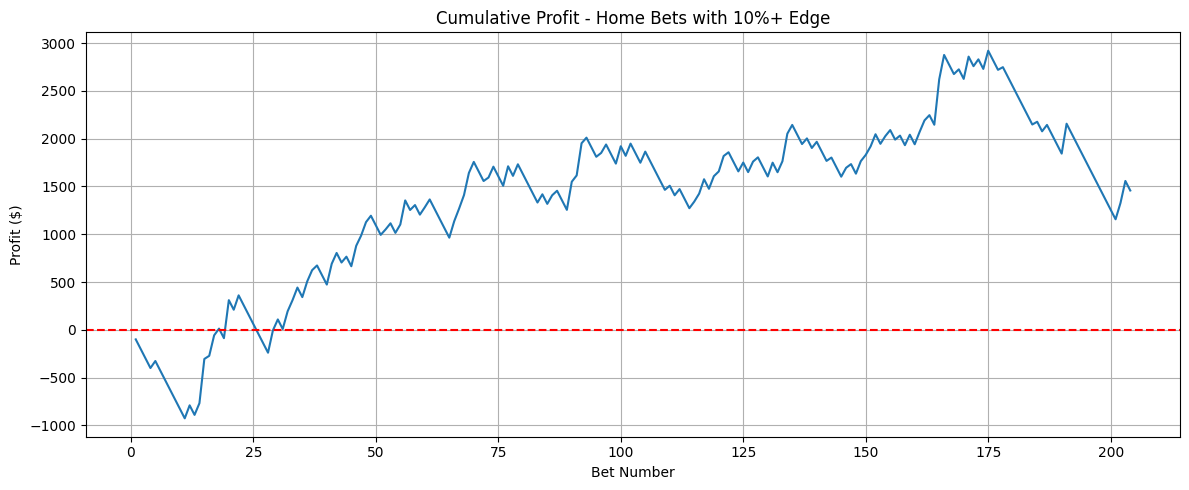


Total bets: 204
Win rate: 0.471
Total profit: $1457.49
ROI: 7.1%
Max drawdown: $-926.25


In [74]:
import matplotlib.pyplot as plt

# Use 10% threshold, home only
bets_final = []
for _, row in merged.iterrows():
    if row['edge'] > 0.10:
        vegas_decimal = 1 / row['vegas_prob_home']
        profit = (vegas_decimal - 1) * STAKE if row['home_win'] == 1 else -STAKE
        bets_final.append({
            'profit': profit,
            'won': row['home_win'],
            'edge': row['edge'],
            'game_date': row['game_date'],
            'matchup': f"{row['team_name_home']} vs {row['team_name_away']}",
            'pred_proba': row['pred_proba'],
            'vegas_prob': row['vegas_prob_home']
        })

bets_final_df = pd.DataFrame(bets_final).sort_values('game_date')
bets_final_df['cumulative_profit'] = bets_final_df['profit'].cumsum()
bets_final_df['bet_number'] = range(1, len(bets_final_df) + 1)

plt.figure(figsize=(12, 5))
plt.plot(bets_final_df['bet_number'], bets_final_df['cumulative_profit'])
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Cumulative Profit - Home Bets with 10%+ Edge')
plt.xlabel('Bet Number')
plt.ylabel('Profit ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nTotal bets: {len(bets_final_df)}")
print(f"Win rate: {bets_final_df['won'].mean():.3f}")
print(f"Total profit: ${bets_final_df['profit'].sum():.2f}")
print(f"ROI: {bets_final_df['profit'].sum() / (len(bets_final_df) * STAKE) * 100:.1f}%")
print(f"Max drawdown: ${bets_final_df['cumulative_profit'].min():.2f}")

In [75]:
# What seasons does our odds data cover?
print(avg_odds_clean['game_date'].dt.year.value_counts().sort_index())

game_date
2006     416
2007    1200
2008    1242
2009    1269
2010    1271
2011     864
2012    1462
2013    1305
2014    1297
2015    1279
2016    1288
2017    1245
2018     768
Name: count, dtype: int64


In [76]:
# Rebuild model_df5 with team ids included
features2_reset = features2.reset_index(drop=True)

model_df5 = features2_reset[top_features + ['home_win', 'game_date', 'team_id_home', 'team_id_away']].dropna().reset_index(drop=True)

all_season_bets = []

for test_year in range(2012, 2019):
    train_cutoff = f'{test_year}-10-01'
    test_start = f'{test_year}-10-01'
    test_end = f'{test_year+1}-10-01'

    train_mask = model_df5['game_date'] < train_cutoff
    test_mask = (model_df5['game_date'] >= test_start) & (model_df5['game_date'] < test_end)

    if test_mask.sum() == 0:
        continue

    X_tr = model_df5.loc[train_mask, top_features]
    y_tr = model_df5.loc[train_mask, 'home_win']
    X_te = model_df5.loc[test_mask, top_features]
    y_te = model_df5.loc[test_mask, 'home_win']

    sc = StandardScaler()
    X_tr_scaled = sc.fit_transform(X_tr)
    X_te_scaled = sc.transform(X_te)

    lr = LogisticRegression()
    lr.fit(X_tr_scaled, y_tr)
    proba = lr.predict_proba(X_te_scaled)[:, 1]

    season_results = model_df5[test_mask].copy()
    season_results['pred_proba'] = proba
    season_results['game_date'] = pd.to_datetime(season_results['game_date'])
    season_results['team_id_home'] = season_results['team_id_home'].astype(str)
    season_results['team_id_away'] = season_results['team_id_away'].astype(str)

    season_merged = season_results.merge(
        avg_odds_clean[['game_date', 'team_id_home', 'team_id_away', 'vegas_prob']],
        on=['game_date', 'team_id_home', 'team_id_away'],
        how='inner'
    )
    season_merged['vegas_prob_home'] = 1 - season_merged['vegas_prob']
    season_merged['edge'] = season_merged['pred_proba'] - season_merged['vegas_prob_home']

    for _, row in season_merged.iterrows():
        if row['edge'] > 0.10:
            vegas_decimal = 1 / row['vegas_prob_home']
            profit = (vegas_decimal - 1) * STAKE if row['home_win'] == 1 else -STAKE
            all_season_bets.append({
                'season': test_year,
                'game_date': row['game_date'],
                'profit': profit,
                'won': row['home_win'],
                'edge': row['edge']
            })

all_bets_df = pd.DataFrame(all_season_bets).sort_values('game_date')
all_bets_df['cumulative_profit'] = all_bets_df['profit'].cumsum()

print(f"Total bets: {len(all_bets_df)}")
print(f"Win rate: {all_bets_df['won'].mean():.3f}")
print(f"Total profit: ${all_bets_df['profit'].sum():.2f}")
print(f"ROI: {all_bets_df['profit'].sum() / (len(all_bets_df) * STAKE) * 100:.1f}%")
print(f"Max drawdown: ${all_bets_df['cumulative_profit'].min():.2f}")
print(f"\nBy season:")
print(all_bets_df.groupby('season').agg(
    bets=('profit', 'count'),
    win_rate=('won', 'mean'),
    profit=('profit', 'sum'),
    roi=('profit', lambda x: x.sum() / (len(x) * STAKE) * 100)
).to_string())

Total bets: 1110
Win rate: 0.470
Total profit: $2433.14
ROI: 2.2%
Max drawdown: $-3664.07

By season:
        bets  win_rate       profit       roi
season                                       
2013     229  0.449782 -1433.710532 -6.260745
2014     242  0.438017   -35.245100 -0.145641
2015     229  0.528384  1433.703103  6.260712
2016     206  0.466019  1010.904124  4.907302
2017     204  0.470588  1457.492672  7.144572


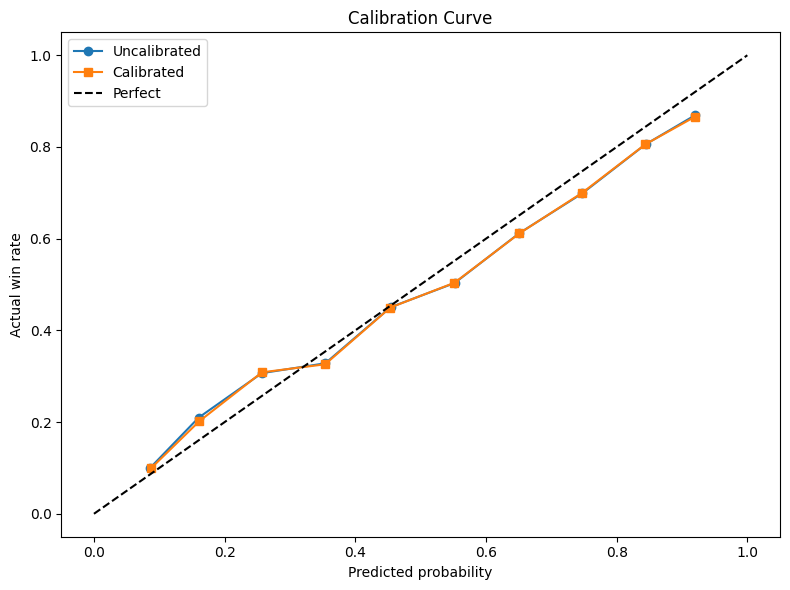

Raw accuracy: 0.644
Calibrated accuracy: 0.645


In [77]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt

# Retrain with calibration on 2012-2016, test on 2017
train_mask = model_df5['game_date'] < '2016-10-01'
test_mask = model_df5['game_date'] >= '2016-10-01'

X_tr = model_df5.loc[train_mask, top_features]
y_tr = model_df5.loc[train_mask, 'home_win']
X_te = model_df5.loc[test_mask, top_features]
y_te = model_df5.loc[test_mask, 'home_win']

sc = StandardScaler()
X_tr_scaled = sc.fit_transform(X_tr)
X_te_scaled = sc.transform(X_te)

# Uncalibrated
lr_raw = LogisticRegression()
lr_raw.fit(X_tr_scaled, y_tr)
proba_raw = lr_raw.predict_proba(X_te_scaled)[:, 1]

# Calibrated with Platt scaling
lr_cal = CalibratedClassifierCV(LogisticRegression(), method='sigmoid', cv=5)
lr_cal.fit(X_tr_scaled, y_tr)
proba_cal = lr_cal.predict_proba(X_te_scaled)[:, 1]

# Plot calibration curves
fig, ax = plt.subplots(figsize=(8, 6))
prob_true_raw, prob_pred_raw = calibration_curve(y_te, proba_raw, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_te, proba_cal, n_bins=10)

ax.plot(prob_pred_raw, prob_true_raw, label='Uncalibrated', marker='o')
ax.plot(prob_pred_cal, prob_true_cal, label='Calibrated', marker='s')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Actual win rate')
ax.set_title('Calibration Curve')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Raw accuracy: {accuracy_score(y_te, (proba_raw > 0.5).astype(int)):.3f}")
print(f"Calibrated accuracy: {accuracy_score(y_te, (proba_cal > 0.5).astype(int)):.3f}")

In [81]:
import numpy as np
import pandas as pd


def find_team_id(team_name):
    """
    Find a team_id from the game table using either home or away team name columns.
    Returns team_id as a string.
    """
    team_name = str(team_name)

    home_matches = game[
        game["team_name_home"].str.contains(team_name, case=False, na=False)
    ][["team_name_home", "team_id_home"]].drop_duplicates()

    away_matches = game[
        game["team_name_away"].str.contains(team_name, case=False, na=False)
    ][["team_name_away", "team_id_away"]].drop_duplicates()

    candidates = []

    for _, row in home_matches.iterrows():
        candidates.append((row["team_name_home"], row["team_id_home"]))

    for _, row in away_matches.iterrows():
        candidates.append((row["team_name_away"], row["team_id_away"]))

    # Remove duplicates
    unique_candidates = []
    seen = set()

    for name, team_id in candidates:
        key = (name, team_id)
        if key not in seen:
            unique_candidates.append((name, team_id))
            seen.add(key)

    if len(unique_candidates) == 0:
        raise ValueError(f"No team found matching: {team_name}")

    if len(unique_candidates) > 1:
        print(f"Multiple matches found for '{team_name}'. Using first match:")
        for name, team_id in unique_candidates[:5]:
            print(f"  {name} — {team_id}")

    return str(unique_candidates[0][1]), unique_candidates[0][0]


def latest_player_elo_features(team_id):
    """
    Get latest player Elo features for a team:
    average Elo, top 5 Elo, and max Elo.
    """
    df = elo_df2.copy()
    df["team_id"] = df["team_id"].astype(str)

    if "game_date" in df.columns:
        df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")
        df = df.sort_values("game_date")

    team_players = (
        df[df["team_id"] == str(team_id)]
        .groupby("player_id")
        .last()
    )

    if team_players.empty:
        raise ValueError(f"No player Elo rows found for team_id={team_id}")

    avg_elo = team_players["elo_before"].mean()
    top5_elo = team_players["elo_before"].nlargest(5).mean()
    max_elo = team_players["elo_before"].max()

    return avg_elo, top5_elo, max_elo


def latest_team_stats(team_id):
    """
    Get latest rolling team stats for a team.
    """
    df = team_game_stats.copy()
    df["team_id"] = df["team_id"].astype(str)

    if "game_date" in df.columns:
        df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")
        df = df.sort_values("game_date")

    team_rows = df[df["team_id"] == str(team_id)]

    if team_rows.empty:
        raise ValueError(f"No rolling stat rows found for team_id={team_id}")

    return team_rows.iloc[-1]


def latest_team_win_rate(team_id, n=5, current_date=None):
    """
    Compute a team's win rate over its most recent n games before current_date.

    This creates a team-level history from model_df5 by stacking home and away games.
    """
    df = model_df5.copy()
    df["game_date"] = pd.to_datetime(df["game_date"], errors="coerce")

    if current_date is None:
        current_date = df["game_date"].max() + pd.Timedelta(days=1)
    else:
        current_date = pd.to_datetime(current_date)

    # Home-team perspective
    home_games = df[["game_date", "team_id_home", "home_win"]].rename(
        columns={
            "team_id_home": "team_id",
            "home_win": "win"
        }
    )

    # Away-team perspective
    away_games = df[["game_date", "team_id_away", "home_win"]].rename(
        columns={
            "team_id_away": "team_id"
        }
    )
    away_games["win"] = 1 - away_games["home_win"]
    away_games = away_games[["game_date", "team_id", "win"]]

    team_games = pd.concat([home_games, away_games], ignore_index=True)
    team_games["team_id"] = team_games["team_id"].astype(str)

    hist = (
        team_games[
            (team_games["team_id"] == str(team_id)) &
            (team_games["game_date"] < current_date)
        ]
        .sort_values("game_date")
    )

    if hist.empty:
        raise ValueError(f"No win-rate history found for team_id={team_id}")

    return hist["win"].tail(n).mean()


def american_to_implied_prob(odds):
    """
    Convert American odds to implied probability.
    Example:
      -150 -> 0.600
      +120 -> 0.455
    """
    if odds is None:
        return None

    odds = float(odds)

    if odds < 0:
        return -odds / (-odds + 100)
    else:
        return 100 / (odds + 100)


def predict_game(
    home_team_name,
    away_team_name,
    current_date=None,
    rest_days_home=2,
    rest_days_away=2,
    vegas_home_prob=None,
    vegas_home_odds=None
):
    """
    Predict home win probability for an NBA matchup using the trained model.

    Required existing notebook objects:
      - game
      - elo_df2
      - team_game_stats
      - model_df5
      - top_features
      - sc
      - lr_cal
    """

    # If current_date is not supplied, use the day after the latest game in model_df5
    if current_date is None:
        current_date = pd.to_datetime(model_df5["game_date"], errors="coerce").max() + pd.Timedelta(days=1)
    else:
        current_date = pd.to_datetime(current_date)

    # Find team IDs
    home_id, home_name_clean = find_team_id(home_team_name)
    away_id, away_name_clean = find_team_id(away_team_name)

    # Elo features
    home_avg_elo, home_top5_elo, home_max_elo = latest_player_elo_features(home_id)
    away_avg_elo, away_top5_elo, away_max_elo = latest_player_elo_features(away_id)

    # Rolling team stats
    home_stats = latest_team_stats(home_id)
    away_stats = latest_team_stats(away_id)

    # Win-rate features
    home_l20 = latest_team_win_rate(home_id, n=20, current_date=current_date)
    away_l20 = latest_team_win_rate(away_id, n=20, current_date=current_date)

    home_l5 = latest_team_win_rate(home_id, n=5, current_date=current_date)
    away_l5 = latest_team_win_rate(away_id, n=5, current_date=current_date)

    # Rest features
    rest_days_home = np.clip(rest_days_home, 1, 14)
    rest_days_away = np.clip(rest_days_away, 1, 14)
    rest_diff = rest_days_home - rest_days_away

    # Build model input
    features_input = pd.DataFrame([{
        "avg_elo_home": home_avg_elo,
        "avg_elo_away": away_avg_elo,
        "top5_elo_home": home_top5_elo,
        "top5_elo_away": away_top5_elo,
        "max_elo_home": home_max_elo,
        "max_elo_away": away_max_elo,

        "roll10_plus_minus_home": home_stats["roll10_plus_minus"],
        "roll10_plus_minus_away": away_stats["roll10_plus_minus"],
        "roll10_pts_home": home_stats["roll10_pts"],
        "roll10_pts_away": away_stats["roll10_pts"],

        "roll10_plus_minus_diff": home_stats["roll10_plus_minus"] - away_stats["roll10_plus_minus"],
        "roll10_pts_diff": home_stats["roll10_pts"] - away_stats["roll10_pts"],

        "elo_diff": home_avg_elo - away_avg_elo,
        "top5_elo_diff": home_top5_elo - away_top5_elo,

        "win_rate_l20_home": home_l20,
        "win_rate_l20_away": away_l20,
        "win_rate_l20_diff": home_l20 - away_l20,

        # Your model uses only the L5 difference, not separate L5 home/away columns
        "win_rate_l5_diff": home_l5 - away_l5,

        "rest_days_home": rest_days_home,
        "rest_days_away": rest_days_away,
        "rest_diff": rest_diff,
    }])

    # Confirm that model input matches training features
    missing_features = [col for col in top_features if col not in features_input.columns]

    if missing_features:
        raise ValueError(f"Missing required model features: {missing_features}")

    nan_features = features_input[top_features].columns[
        features_input[top_features].isna().any()
    ].tolist()

    if nan_features:
        raise ValueError(f"These model features contain NaN values: {nan_features}")

    # Scale and predict
    scaled = sc.transform(features_input[top_features])
    home_prob = lr_cal.predict_proba(scaled)[0][1]
    away_prob = 1 - home_prob

    # Optional Vegas probability
    if vegas_home_prob is None and vegas_home_odds is not None:
        vegas_home_prob = american_to_implied_prob(vegas_home_odds)

    # Print result
    print(f"\n{'=' * 60}")
    print(f"{home_name_clean} (home) vs {away_name_clean}")
    print(f"{'=' * 60}")
    print(f"Our model: Home {home_prob:.1%} / Away {away_prob:.1%}")

    if vegas_home_prob is not None:
        edge = home_prob - vegas_home_prob
        print(f"Vegas:     Home {vegas_home_prob:.1%} / Away {1 - vegas_home_prob:.1%}")
        print(f"Edge:      {edge:+.1%}")

        if edge >= 0.08:
            print("Signal:    Potential HOME value")
        else:
            print("Signal:    No strong home-team edge")

    print("\nKey features:")
    print(f"Home Elo: avg={home_avg_elo:.0f}, top5={home_top5_elo:.0f}, max={home_max_elo:.0f}")
    print(f"Away Elo: avg={away_avg_elo:.0f}, top5={away_top5_elo:.0f}, max={away_max_elo:.0f}")
    print(f"Elo diff: {home_avg_elo - away_avg_elo:+.1f}")
    print(f"Top 5 Elo diff: {home_top5_elo - away_top5_elo:+.1f}")
    print(f"Home last 10 +/-: {home_stats['roll10_plus_minus']:+.1f}")
    print(f"Away last 10 +/-: {away_stats['roll10_plus_minus']:+.1f}")
    print(f"L20 win-rate diff: {home_l20 - away_l20:+.1%}")
    print(f"L5 win-rate diff: {home_l5 - away_l5:+.1%}")
    print(f"Rest diff: {rest_diff:+.0f} days")

    return {
        "home_team": home_name_clean,
        "away_team": away_name_clean,
        "home_team_id": home_id,
        "away_team_id": away_id,
        "home_prob": home_prob,
        "away_prob": away_prob,
        "vegas_home_prob": vegas_home_prob,
        "edge": None if vegas_home_prob is None else home_prob - vegas_home_prob,
        "features": features_input
    }

In [82]:
print([c for c in model_df5.columns if "win_rate" in c.lower()])
print("\nTop features:")
print(top_features)

['win_rate_l20_diff', 'win_rate_l20_home', 'win_rate_l20_away', 'win_rate_l5_diff']

Top features:
['elo_diff', 'top5_elo_diff', 'avg_elo_home', 'avg_elo_away', 'top5_elo_home', 'top5_elo_away', 'max_elo_home', 'max_elo_away', 'roll10_plus_minus_diff', 'roll10_plus_minus_home', 'roll10_plus_minus_away', 'roll10_pts_diff', 'win_rate_l20_diff', 'win_rate_l20_home', 'win_rate_l20_away', 'win_rate_l5_diff', 'rest_diff', 'rest_days_home', 'rest_days_away']


In [83]:
def predict_game(home_team_name, away_team_name, rest_days_home=2, rest_days_away=2):
    # Find team ids
    home_matches = game[game['team_name_home'].str.contains(home_team_name, case=False)]
    away_matches = game[game['team_name_away'].str.contains(away_team_name, case=False)]

    if len(home_matches) == 0:
        print(f"Can't find home team: {home_team_name}")
        return
    if len(away_matches) == 0:
        print(f"Can't find away team: {away_team_name}")
        return

    home_id = str(home_matches.iloc[0]['team_id_home'])
    away_id = str(away_matches.iloc[0]['team_id_away'])

    # Latest player elos per team
    home_players = elo_df2[elo_df2['team_id'] == home_id].groupby('player_id').last()
    away_players = elo_df2[elo_df2['team_id'] == away_id].groupby('player_id').last()

    home_avg_elo = home_players['elo_before'].mean()
    home_top5_elo = home_players['elo_before'].nlargest(5).mean()
    home_max_elo = home_players['elo_before'].max()
    away_avg_elo = away_players['elo_before'].mean()
    away_top5_elo = away_players['elo_before'].nlargest(5).mean()
    away_max_elo = away_players['elo_before'].max()

    # Latest rolling team stats
    home_ts = team_game_stats[team_game_stats['team_id'].astype(str) == home_id]
    away_ts = team_game_stats[team_game_stats['team_id'].astype(str) == away_id]

    if len(home_ts) == 0 or len(away_ts) == 0:
        print(f"Missing team stats for {home_team_name} ({home_id}) or {away_team_name} ({away_id})")
        return

    home_stats = home_ts.iloc[-1]
    away_stats = away_ts.iloc[-1]

    # Latest win rates from features2
    home_f_rows = features2[features2['team_id_home'].astype(str) == home_id]
    away_f_rows = features2[features2['team_id_away'].astype(str) == away_id]

    if len(home_f_rows) == 0 or len(away_f_rows) == 0:
        print(f"Missing win rate data for {home_team_name} or {away_team_name}")
        return

    home_f = home_f_rows.iloc[-1]
    away_f = away_f_rows.iloc[-1]

    win_rate_l5_home = home_f['win_rate_l5_home']
    win_rate_l20_home = home_f['win_rate_l20_home']
    win_rate_l5_away = away_f['win_rate_l5_away']
    win_rate_l20_away = away_f['win_rate_l20_away']

    features_input = pd.DataFrame([{
        'avg_elo_home': home_avg_elo, 'avg_elo_away': away_avg_elo,
        'top5_elo_home': home_top5_elo, 'top5_elo_away': away_top5_elo,
        'max_elo_home': home_max_elo, 'max_elo_away': away_max_elo,
        'roll10_plus_minus_home': home_stats['roll10_plus_minus'],
        'roll10_plus_minus_away': away_stats['roll10_plus_minus'],
        'roll10_pts_home': home_stats['roll10_pts'],
        'roll10_pts_away': away_stats['roll10_pts'],
        'roll10_plus_minus_diff': home_stats['roll10_plus_minus'] - away_stats['roll10_plus_minus'],
        'roll10_pts_diff': home_stats['roll10_pts'] - away_stats['roll10_pts'],
        'elo_diff': home_avg_elo - away_avg_elo,
        'top5_elo_diff': home_top5_elo - away_top5_elo,
        'win_rate_l5_home': win_rate_l5_home, 'win_rate_l20_home': win_rate_l20_home,
        'win_rate_l5_away': win_rate_l5_away, 'win_rate_l20_away': win_rate_l20_away,
        'win_rate_l20_diff': win_rate_l20_home - win_rate_l20_away,
        'win_rate_l5_diff': win_rate_l5_home - win_rate_l5_away,
        'rest_days_home': rest_days_home, 'rest_days_away': rest_days_away,
        'rest_diff': rest_days_home - rest_days_away,
    }])

    scaled = sc.transform(features_input[top_features])
    prob = lr_cal.predict_proba(scaled)[0][1]

    print(f"\n{'='*45}")
    print(f"  {home_team_name} (home) vs {away_team_name}")
    print(f"{'='*45}")
    print(f"  Home win probability:  {prob:.1%}")
    print(f"  Away win probability:  {1-prob:.1%}")
    print(f"\n  Home Elo: avg={home_avg_elo:.0f}, top5={home_top5_elo:.0f}, max={home_max_elo:.0f}")
    print(f"  Away Elo: avg={away_avg_elo:.0f}, top5={away_top5_elo:.0f}, max={away_max_elo:.0f}")
    print(f"\n  Home last 10 +/-: {home_stats['roll10_plus_minus']:.1f}")
    print(f"  Away last 10 +/-: {away_stats['roll10_plus_minus']:.1f}")
    print(f"  Home L5 win rate: {win_rate_l5_home:.0%}")
    print(f"  Away L5 win rate: {win_rate_l5_away:.0%}")

predict_game("Denver Nuggets", "Miami Heat")
predict_game("Milwaukee Bucks", "Chicago Bulls")

Missing win rate data for Denver Nuggets or Miami Heat

  Milwaukee Bucks (home) vs Chicago Bulls
  Home win probability:  83.6%
  Away win probability:  16.4%

  Home Elo: avg=1275, top5=1450, max=1465
  Away Elo: avg=1243, top5=1452, max=1466

  Home last 10 +/-: 3.7
  Away last 10 +/-: 1.3
  Home L5 win rate: 80%
  Away L5 win rate: 40%


In [84]:
predict_game("Golden State Warriors", "Sacramento Kings")
predict_game("Denver Nuggets", "Miami Heat")
predict_game("Milwaukee Bucks", "Chicago Bulls")


  Golden State Warriors (home) vs Sacramento Kings
  Home win probability:  72.6%
  Away win probability:  27.4%

  Home Elo: avg=1246, top5=1478, max=1491
  Away Elo: avg=1254, top5=1436, max=1440

  Home last 10 +/-: 6.3
  Away last 10 +/-: 3.7
  Home L5 win rate: 60%
  Away L5 win rate: 40%
Missing win rate data for Denver Nuggets or Miami Heat

  Milwaukee Bucks (home) vs Chicago Bulls
  Home win probability:  83.6%
  Away win probability:  16.4%

  Home Elo: avg=1275, top5=1450, max=1465
  Away Elo: avg=1243, top5=1452, max=1466

  Home last 10 +/-: 3.7
  Away last 10 +/-: 1.3
  Home L5 win rate: 80%
  Away L5 win rate: 40%


In [85]:
new_seasons = ['2023-24', '2024-25']
new_gamelogs = []

for season in new_seasons:
    try:
        gamelog = leaguegamelog.LeagueGameLog(season=season, player_or_team_abbreviation='P')
        df = gamelog.get_data_frames()[0]
        new_gamelogs.append(df)
        print(f"{season}: {len(df)} rows")
        time.sleep(1)
    except Exception as e:
        print(f"{season} failed: {e}")

new_gamelogs_df = pd.concat(new_gamelogs, ignore_index=True)
print(f"Total new rows: {len(new_gamelogs_df)}")

2023-24: 26401 rows
2024-25: 26306 rows
Total new rows: 52707


In [86]:
# Combine old and new
new_gamelogs_df['GAME_DATE'] = pd.to_datetime(new_gamelogs_df['GAME_DATE'])
new_gamelogs_df['GAME_ID'] = new_gamelogs_df['GAME_ID'].astype(str)
new_gamelogs_df['TEAM_ID'] = new_gamelogs_df['TEAM_ID'].astype(str)

# Add perf_score to new data
new_gamelogs_df['PLUS_MINUS'] = new_gamelogs_df['PLUS_MINUS'].fillna(0)
new_gamelogs_df['MIN'] = pd.to_numeric(new_gamelogs_df['MIN'], errors='coerce').fillna(0)
for col in ['PTS', 'REB', 'AST', 'STL', 'BLK', 'TOV']:
    new_gamelogs_df[col] = new_gamelogs_df[col].fillna(0)

new_gamelogs_df['perf_score'] = (
    new_gamelogs_df['PTS'] * 1.0 +
    new_gamelogs_df['REB'] * 1.2 +
    new_gamelogs_df['AST'] * 1.5 +
    new_gamelogs_df['STL'] * 2.0 +
    new_gamelogs_df['BLK'] * 2.0 +
    new_gamelogs_df['TOV'] * -1.0 +
    new_gamelogs_df['PLUS_MINUS'] * 0.5
)

all_gamelogs_full = pd.concat([player_gamelogs, new_gamelogs_df], ignore_index=True)
all_gamelogs_full = all_gamelogs_full.sort_values('GAME_DATE').reset_index(drop=True)

print(f"Total rows: {len(all_gamelogs_full)}")
print(f"Date range: {all_gamelogs_full['GAME_DATE'].min()} to {all_gamelogs_full['GAME_DATE'].max()}")

Total rows: 736164
Date range: 1996-11-01 00:00:00 to 2025-04-13 00:00:00


In [87]:
K = 20
LEGACY_FLOOR = 1400
LEGACY_GAMES = 400
DEFAULT_ELO = 1200
DECAY_HALFLIFE = 365

player_elo = {}
player_games = {}
player_peak_elo = {}
player_last_game = {}

elo_records_full = []

for _, row in all_gamelogs_full.iterrows():
    pid = row['PLAYER_ID']
    game_date = row['GAME_DATE']

    elo = player_elo.get(pid, DEFAULT_ELO)
    games_played = player_games.get(pid, 0)
    peak = player_peak_elo.get(pid, DEFAULT_ELO)
    last_game = player_last_game.get(pid, game_date)

    days_inactive = (game_date - last_game).days
    if days_inactive > 30:
        decay = 0.5 ** (days_inactive / DECAY_HALFLIFE)
        elo = DEFAULT_ELO + (elo - DEFAULT_ELO) * decay

    elo_records_full.append({
        'game_id': row['GAME_ID'],
        'player_id': pid,
        'player_name': row['PLAYER_NAME'],
        'team_id': str(row['TEAM_ID']),
        'game_date': game_date,
        'elo_before': elo,
        'peak_elo': peak,
        'games_played': games_played,
        'won': 1 if row['WL'] == 'W' else 0
    })

    perf_weight = np.clip(row['perf_score'] / 30, 0.5, 2.5)
    k_adjusted = K * perf_weight
    expected = 1 / (1 + 10 ** ((DEFAULT_ELO - elo) / 400))
    actual = 1 if row['WL'] == 'W' else 0
    new_elo = elo + k_adjusted * (actual - expected)

    if games_played > LEGACY_GAMES:
        legacy_floor = LEGACY_FLOOR + (peak - LEGACY_FLOOR) * 0.3
        new_elo = max(new_elo, legacy_floor)

    player_elo[pid] = new_elo
    player_peak_elo[pid] = max(peak, new_elo)
    player_games[pid] = games_played + 1
    player_last_game[pid] = game_date

elo_df_full = pd.DataFrame(elo_records_full)
print(f"Done! {elo_df_full.shape}")

# Sanity check top players
final_elos_full = pd.DataFrame([
    {'player_id': pid, 'elo': elo, 'games_played': player_games[pid]}
    for pid, elo in player_elo.items()
])
name_map = elo_df_full[['player_id', 'player_name']].drop_duplicates('player_id')
final_elos_full = final_elos_full.merge(name_map, on='player_id')
final_elos_full = final_elos_full[final_elos_full['games_played'] >= 200].sort_values('elo', ascending=False)
print(final_elos_full.head(15).to_string())

Done! (736164, 9)
      player_id          elo  games_played              player_name
2048    1628983  1516.495679           537  Shai Gilgeous-Alexander
1319     201935  1505.175970          1223             James Harden
1768     204001  1504.532082           558       Kristaps Porziņģis
1447     202695  1502.067329           801            Kawhi Leonard
1921    1628401  1497.768045           567            Derrick White
1590     203507  1497.063592           932    Giannis Antetokounmpo
1331     201950  1496.509883          1106             Jrue Holiday
1904    1628369  1495.306004           659             Jayson Tatum
2049    1628392  1490.268731           454       Isaiah Hartenstein
1871    1627826  1484.039559           652              Ivica Zubac
1661     203944  1481.032593           756            Julius Randle
1594     203497  1479.683721           905              Rudy Gobert
2027    1629026  1476.967202           460         Kenrich Williams
1188     201143  1474.509697  

In [88]:
# Pull new game data from NBA API for 2023-24 and 2024-25
from nba_api.stats.endpoints import leaguegamelog

new_team_logs = []
for season in ['2023-24', '2024-25']:
    gl = leaguegamelog.LeagueGameLog(season=season, player_or_team_abbreviation='T')
    df = gl.get_data_frames()[0]
    new_team_logs.append(df)
    print(f"{season}: {len(df)} rows")
    time.sleep(1)

new_team_df = pd.concat(new_team_logs, ignore_index=True)
print(new_team_df.columns.tolist())

2023-24: 2460 rows
2024-25: 2460 rows
['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'PLUS_MINUS', 'VIDEO_AVAILABLE']


In [89]:
# Format new team logs to match our team_game_stats format
new_team_df['GAME_DATE'] = pd.to_datetime(new_team_df['GAME_DATE'])
new_team_df['TEAM_ID'] = new_team_df['TEAM_ID'].astype(str)
new_team_df['GAME_ID'] = new_team_df['GAME_ID'].astype(str)
new_team_df['is_home'] = new_team_df['MATCHUP'].apply(lambda x: 0 if '@' in x else 1)

new_team_stats = new_team_df[['GAME_ID', 'GAME_DATE', 'TEAM_ID', 'PTS', 'PLUS_MINUS',
                               'FG_PCT', 'FG3_PCT', 'FT_PCT', 'REB', 'AST', 'TOV', 'is_home']].copy()
new_team_stats.columns = ['game_id', 'game_date', 'team_id', 'pts', 'plus_minus',
                           'fg_pct', 'fg3_pct', 'ft_pct', 'reb', 'ast', 'tov', 'is_home']

# Combine with existing team_game_stats
team_game_stats['team_id'] = team_game_stats['team_id'].astype(str)
team_game_stats_full = pd.concat([team_game_stats, new_team_stats], ignore_index=True)
team_game_stats_full = team_game_stats_full.sort_values(['team_id', 'game_date']).reset_index(drop=True)

# Recompute rolling stats
for col in roll_cols:
    team_game_stats_full[f'roll10_{col}'] = (
        team_game_stats_full.groupby('team_id')[col]
        .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
    )

# Also compute rolling win rate
team_game_stats_full['win'] = (new_team_df['WL'] == 'W').astype(int) if False else None
all_wl_new = new_team_df[['GAME_ID', 'GAME_DATE', 'TEAM_ID', 'WL']].copy()
all_wl_new.columns = ['game_id', 'game_date', 'team_id', 'wl']
all_wl_new['win'] = (all_wl_new['wl'] == 'W').astype(int)
all_wl_new['team_id'] = all_wl_new['team_id'].astype(str)
all_wl_new['game_date'] = pd.to_datetime(all_wl_new['game_date'])

all_wl_full = pd.concat([all_wl, all_wl_new], ignore_index=True)
all_wl_full = all_wl_full.sort_values(['team_id', 'game_date']).reset_index(drop=True)
all_wl_full['win_rate_l5'] = all_wl_full.groupby('team_id')['win'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=3).mean()
)
all_wl_full['win_rate_l20'] = all_wl_full.groupby('team_id')['win'].transform(
    lambda x: x.shift(1).rolling(20, min_periods=10).mean()
)

print("Done!")
print(team_game_stats_full.shape)
print(f"Date range: {team_game_stats_full['game_date'].min()} to {team_game_stats_full['game_date'].max()}")

Done!
(125304, 21)
Date range: 1946-11-01 00:00:00 to 2025-04-13 00:00:00


In [90]:
def predict_game(home_team_name, away_team_name, rest_days_home=2, rest_days_away=2):
    # Find team ids
    home_matches = game[game['team_name_home'].str.contains(home_team_name, case=False)]
    away_matches = game[game['team_name_away'].str.contains(away_team_name, case=False)]

    if len(home_matches) == 0:
        print(f"Can't find home team: {home_team_name}")
        return None
    if len(away_matches) == 0:
        print(f"Can't find away team: {away_team_name}")
        return None

    home_id = str(home_matches.iloc[0]['team_id_home'])
    away_id = str(away_matches.iloc[0]['team_id_away'])

    # Latest player elos per team
    home_players = elo_df_full[elo_df_full['team_id'] == home_id].groupby('player_id').last()
    away_players = elo_df_full[elo_df_full['team_id'] == away_id].groupby('player_id').last()

    home_avg_elo = home_players['elo_before'].mean()
    home_top5_elo = home_players['elo_before'].nlargest(5).mean()
    home_max_elo = home_players['elo_before'].max()
    away_avg_elo = away_players['elo_before'].mean()
    away_top5_elo = away_players['elo_before'].nlargest(5).mean()
    away_max_elo = away_players['elo_before'].max()

    # Latest rolling team stats
    home_ts = team_game_stats_full[team_game_stats_full['team_id'] == home_id]
    away_ts = team_game_stats_full[team_game_stats_full['team_id'] == away_id]

    if len(home_ts) == 0 or len(away_ts) == 0:
        print(f"Missing team stats")
        return None

    home_stats = home_ts.iloc[-1]
    away_stats = away_ts.iloc[-1]

    # Latest win rates
    home_wl = all_wl_full[all_wl_full['team_id'] == home_id].iloc[-1]
    away_wl = all_wl_full[all_wl_full['team_id'] == away_id].iloc[-1]

    win_rate_l5_home = home_wl['win_rate_l5']
    win_rate_l20_home = home_wl['win_rate_l20']
    win_rate_l5_away = away_wl['win_rate_l5']
    win_rate_l20_away = away_wl['win_rate_l20']

    features_input = pd.DataFrame([{
        'avg_elo_home': home_avg_elo, 'avg_elo_away': away_avg_elo,
        'top5_elo_home': home_top5_elo, 'top5_elo_away': away_top5_elo,
        'max_elo_home': home_max_elo, 'max_elo_away': away_max_elo,
        'roll10_plus_minus_home': home_stats['roll10_plus_minus'],
        'roll10_plus_minus_away': away_stats['roll10_plus_minus'],
        'roll10_pts_home': home_stats['roll10_pts'],
        'roll10_pts_away': away_stats['roll10_pts'],
        'roll10_plus_minus_diff': home_stats['roll10_plus_minus'] - away_stats['roll10_plus_minus'],
        'roll10_pts_diff': home_stats['roll10_pts'] - away_stats['roll10_pts'],
        'elo_diff': home_avg_elo - away_avg_elo,
        'top5_elo_diff': home_top5_elo - away_top5_elo,
        'win_rate_l5_home': win_rate_l5_home, 'win_rate_l20_home': win_rate_l20_home,
        'win_rate_l5_away': win_rate_l5_away, 'win_rate_l20_away': win_rate_l20_away,
        'win_rate_l20_diff': win_rate_l20_home - win_rate_l20_away,
        'win_rate_l5_diff': win_rate_l5_home - win_rate_l5_away,
        'rest_days_home': rest_days_home, 'rest_days_away': rest_days_away,
        'rest_diff': rest_days_home - rest_days_away,
    }])

    scaled = sc.transform(features_input[top_features])
    prob = lr_cal.predict_proba(scaled)[0][1]

    return {
        'home_team': home_team_name,
        'away_team': away_team_name,
        'home_prob': prob,
        'away_prob': 1 - prob,
        'home_avg_elo': home_avg_elo,
        'away_avg_elo': away_avg_elo,
        'home_top5_elo': home_top5_elo,
        'away_top5_elo': away_top5_elo,
        'home_pm': home_stats['roll10_plus_minus'],
        'away_pm': away_stats['roll10_plus_minus'],
        'home_l5': win_rate_l5_home,
        'away_l5': win_rate_l5_away,
    }

def show_prediction(home_team, away_team, rest_days_home=2, rest_days_away=2, vegas_home_prob=None):
    result = predict_game(home_team, away_team, rest_days_home, rest_days_away)
    if result is None:
        return

    print(f"\n{'='*45}")
    print(f"  {home_team} (home) vs {away_team}")
    print(f"{'='*45}")
    print(f"  Our model:  Home {result['home_prob']:.1%}  /  Away {result['away_prob']:.1%}")

    if vegas_home_prob:
        edge = result['home_prob'] - vegas_home_prob
        print(f"  Vegas:      Home {vegas_home_prob:.1%}  /  Away {1-vegas_home_prob:.1%}")
        print(f"  Edge:       {edge:+.1%} {'✓ BET HOME' if edge > 0.10 else '✗ no bet'}")

    print(f"\n  Home Elo: avg={result['home_avg_elo']:.0f}, top5={result['home_top5_elo']:.0f}")
    print(f"  Away Elo: avg={result['away_avg_elo']:.0f}, top5={result['away_top5_elo']:.0f}")
    print(f"  Home last 10 +/-: {result['home_pm']:.1f}  |  L5 win rate: {result['home_l5']:.0%}")
    print(f"  Away last 10 +/-: {result['away_pm']:.1f}  |  L5 win rate: {result['away_l5']:.0%}")

# Test
show_prediction("Boston Celtics", "Los Angeles Lakers")
show_prediction("Oklahoma City Thunder", "Cleveland Cavaliers", vegas_home_prob=0.62)


  Boston Celtics (home) vs Los Angeles Lakers
  Our model:  Home 76.6%  /  Away 23.4%

  Home Elo: avg=1276, top5=1490
  Away Elo: avg=1290, top5=1467
  Home last 10 +/-: 12.3  |  L5 win rate: 80%
  Away last 10 +/-: 7.8  |  L5 win rate: 80%

  Oklahoma City Thunder (home) vs Cleveland Cavaliers
  Our model:  Home 88.4%  /  Away 11.6%
  Vegas:      Home 62.0%  /  Away 38.0%
  Edge:       +26.4% ✓ BET HOME

  Home Elo: avg=1283, top5=1479
  Away Elo: avg=1251, top5=1474
  Home last 10 +/-: 12.4  |  L5 win rate: 60%
  Away last 10 +/-: 5.2  |  L5 win rate: 60%
